# Figure 3 — Mechanistic hypotheses for five DEPICT-prioritized top-50 candidates

Got all the output plots for the new compound discovery case.

## Full-Hallmark similarity and composite-ready revision

This interactive notebook analyzes five literature-prioritized DEPICT candidates in A549:

- BRD-K26381032
- CCT036477
- methyl-benzethonium
- BG-1026
- XMD-16144

The revision separates the visual and discovery roles of the pathway analyses: Figure 3A uses the prespecified NSCLC-focused panel, whereas Figures 3B and 3C use a quality-controlled full Hallmark representation. All main panels are exported at coordinated dimensions for later assembly into a single asymmetric canvas.


## Cosmetic revision in this version

- Figure 3A candidate labels now use the same regular font weight as reference drugs.
- All Figure 3B variants omit internal titles to maximize vertical space.
- Figure 3B legends are moved farther above the axes, with extra top and bottom margins to reduce overlap with point labels and the x-axis.


## 0. User-editable configuration

Edit only this cell first. The default project directory is set to your `DrugScreening` folder. The file resolver will search this folder and its common subfolders for the ranking, DGE, signature, GMT, and FDA synonym table files.

In [1]:
from pathlib import Path

# ---------------------------------------------------------------------
# Main project folder provided by you.
# ---------------------------------------------------------------------
PROJECT_DIR = Path("/work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/analysis/DrugScreening")

# Where outputs from this notebook will be written.
OUT_DIR = PROJECT_DIR / "Figure3_top50_five_candidate_hypothesis_generation"
FIG_DIR = OUT_DIR / "figures"
TABLE_DIR = OUT_DIR / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# Literature-prioritized DEPICT top-50 candidates for the revised Figure 3 analysis.
FIG3_CANDIDATE_NAMES = [
    "BRD-K26381032",
    "CCT036477",
    "methyl-benzethonium",
    "BG-1026",
    "XMD-16144",
]

# Expected ranks from the predicted top-50 screen. The notebook still uses the
# actual rank found in the ranking table for all calculations and labels.
EXPECTED_CANDIDATE_RANKS = {
    "BRD-K26381032": 20,
    "CCT036477": 21,
    "methyl-benzethonium": 37,
    "BG-1026": 40,
    "XMD-16144": 44,
}

# FDA-reference fallback rule.
REFERENCE_TOP_N_PRIMARY = 100
REFERENCE_TOP_N_FALLBACK = 200
MIN_REFERENCE_DRUGS = 3

# Mechanism assignment threshold for Figure 3C.
UNRESOLVED_MIN_RHO = 0.30
UNRESOLVED_MIN_MARGIN = 0.10

# Pathway scoring options.
MIN_LANDMARK_OVERLAP = 10
ALL_HALLMARK_MIN_OVERLAP_FRACTION = 0.10
ALL_HALLMARK_MAX_MISSING_FRACTION = 0.20
ALL_HALLMARK_MIN_VARIANCE = 1e-8
GSEA_WEIGHT_EXPONENT = 1.0
NSCLC_SIGNATURE_IS_ALREADY_REVERSED = False  # keep False if signature is tumor-vs-normal log2FC

print("PROJECT_DIR:", PROJECT_DIR)
# Composite-ready target dimensions (inches).
# Intended final arrangement: 3A left; 3B upper-right; 3C lower-right.
# Illustrator-ready dimensions matched to the finalized Figure 4 panels.
# Figure 3A matches Figure 4C (7.3 x 6.45 in).
# Figure 3B matches the finalized Figure 4A footprint (6.8 x 3.10 in).
# Figure 3C matches the finalized Figure 4B footprint (6.8 x 3.25 in).
# This gives both complete figure rows an aligned total width of ~14.1 in.
FIG3A_SIZE = (7.3, 6.45)
FIG3B_SIZE = (6.8, 3.10)
FIG3C_SIZE = (6.8, 3.25)

print("OUT_DIR:", OUT_DIR)
print("Composite-ready panel sizes:", {"3A": FIG3A_SIZE, "3B": FIG3B_SIZE, "3C": FIG3C_SIZE})


PROJECT_DIR: /work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/analysis/DrugScreening
OUT_DIR: /work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/analysis/DrugScreening/Figure3_top50_five_candidate_hypothesis_generation
Composite-ready panel sizes: {'3A': (7.3, 6.45), '3B': (6.8, 3.1), '3C': (6.8, 3.25)}


## 1. Imports and display settings

This cell loads packages, sets plotting defaults, and defines a small helper for showing data frames interactively.

In [2]:
import re
import warnings
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, pearsonr
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D

from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 80)
pd.set_option("display.width", 180)


# ---------------------------------------------------------------------
# A calm scientific palette.
# - Diverging heatmap: blue-white-red, centered at zero.
# - Categorical colors: Okabe-Ito style, colorblind-aware.
# ---------------------------------------------------------------------
SCIENTIFIC_DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    "scientific_blue_white_red",
    ["#2E5EAA", "#F7F7F7", "#B2182B"],
)

OKABE_ITO = [
    "#0072B2",  # blue
    "#D55E00",  # vermillion
    "#009E73",  # green
    "#CC79A7",  # reddish purple
    "#E69F00",  # orange
    "#56B4E9",  # sky blue
    "#F0E442",  # yellow
    "#000000",  # black
]


def set_publication_style():
    plt.rcParams.update({
        "figure.dpi": 150,
        "savefig.dpi": 600,
        "font.family": "DejaVu Sans",
        "font.size": 8,
        "axes.labelsize": 8.5,
        "axes.titlesize": 9,
        "axes.titleweight": "bold",
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 7,
        "axes.linewidth": 0.8,
        "xtick.major.width": 0.6,
        "ytick.major.width": 0.6,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",
    })

set_publication_style()


def show_df(df, title=None, n=20):
    if title:
        display(Markdown(f"**{title}**"))
    display(df.head(n))
    print(f"shape = {df.shape}")


## 2. Resolve input files

This cell searches for the expected files under `PROJECT_DIR`. If any path is wrong, edit the corresponding path manually after this cell. The notebook will not proceed until all required files exist.

In [3]:
# ---------------------------------------------------------------------
# Candidate names are intentionally broad because previous notebooks may
# have slightly different output names. You can replace any path manually.
# ---------------------------------------------------------------------
FILE_CANDIDATES = {
    "FINAL_DF_PRED_PATH": [
        "reverseScore_predicted_All.csv",
        "final_df_pred.csv",
        "final_df_pred_A549.csv",
        "predicted_reverse_score.csv",
        "predicted_A549_reverse_score.csv",
    ],
    "FINAL_DF_ORIG_PATH": [
        "reverseScore_observed_All.csv",
        "reverseScore_original_All.csv",
        "final_df_orig.csv",
        "final_df_orig_A549.csv",
        "observed_reverse_score.csv",
        "original_A549_reverse_score.csv",
    ],
    "DF_DIFFEXP_PRED_PATH": [
        "diff_geneExp_pred.csv",
        "df_diffexp_pred.csv",
        "predicted_dge.csv",
        "predicted_A549_dge.csv",
    ],
    "DF_DIFFEXP_OBS_PATH": [
        "diff_geneExp_meanPlate.csv",
        "df_diffexp_orig.csv",
        "df_diffexp_obs.csv",
        "observed_dge.csv",
        "original_A549_dge.csv",
    ],
    "NSCLC_SIGNATURE_PATH": [
        "E-GEOD-18842-A-AFFY-44-analytics.tsv",
        "nsclc_signature.tsv",
        "NSCLC_signature.tsv",
    ],
    "HALLMARK_GMT_PATH": [
        "h.all.v2026.1.Hs.symbols.gmt.txt",
        "h.all.v2026.1.Hs.symbols.gmt",
        "h.all.v2025.1.Hs.symbols.gmt.txt",
    ],
    "FDA_NSCLC_SYNONYM_PATH": [
        "fda_approved_nsclc_synonym_table.csv",
    ],
}


def resolve_file(candidate_names, project_dir=PROJECT_DIR, extra_dirs=None, recursive=True):
    extra_dirs = extra_dirs or []
    search_roots = [project_dir, project_dir / "data", project_dir / "Data", project_dir / "tables", project_dir / "Tables"] + [Path(x) for x in extra_dirs]
    for root in search_roots:
        for name in candidate_names:
            p = root / name
            if p.exists():
                return p
    if recursive:
        for name in candidate_names:
            hits = list(project_dir.rglob(name))
            if hits:
                return hits[0]
    return None

resolved = {key: resolve_file(names) for key, names in FILE_CANDIDATES.items()}
for key, path in resolved.items():
    print(f"{key}: {path}")

# Manual overrides can be placed here if needed. Example:
# resolved["FINAL_DF_PRED_PATH"] = PROJECT_DIR / "your_actual_file.csv"

missing = [k for k, v in resolved.items() if v is None or not Path(v).exists()]
if missing:
    print("\nMissing required files:", missing)
    print("Please edit `resolved[...]` above or move the files into PROJECT_DIR / data.")
else:
    print("\nAll required files found.")

FINAL_DF_PRED_PATH = resolved["FINAL_DF_PRED_PATH"]
FINAL_DF_ORIG_PATH = resolved["FINAL_DF_ORIG_PATH"]
DF_DIFFEXP_PRED_PATH = resolved["DF_DIFFEXP_PRED_PATH"]
DF_DIFFEXP_OBS_PATH = resolved["DF_DIFFEXP_OBS_PATH"]
NSCLC_SIGNATURE_PATH = resolved["NSCLC_SIGNATURE_PATH"]
HALLMARK_GMT_PATH = resolved["HALLMARK_GMT_PATH"]
FDA_NSCLC_SYNONYM_PATH = resolved["FDA_NSCLC_SYNONYM_PATH"]

FINAL_DF_PRED_PATH: /work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/analysis/DrugScreening/data/reverseScore_predicted_All.csv
FINAL_DF_ORIG_PATH: /work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/analysis/DrugScreening/data/reverseScore_observed_All.csv
DF_DIFFEXP_PRED_PATH: /work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/analysis/DrugScreening/data/diff_geneExp_pred.csv
DF_DIFFEXP_OBS_PATH: /work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/analysis/DrugScreening/data/diff_geneExp_meanPlate.csv
NSCLC_SIGNATURE_PATH: /work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/analysis/DrugScreening/data/E-GEOD-18842-A-AFFY-44-analytics.tsv
HALLMARK_GMT_PATH: /work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Ju

## 3. Helper functions — names, ranking tables, and FDA synonym matching

These functions normalize drug names, load CSVs, make one best row per drug, expand the FDA synonym table, and choose the observed A549 FDA reference panel.

In [4]:
FDA_MATCH_PRIORITY_ORDER = {
    "small_molecule_targeted": 0,
    "chemotherapy": 1,
    "biologic_or_adc": 2,
}

CANDIDATE_GROUP = {
    "BRD-K26381032": "top-50 candidate; unannotated / unknown target",
    "CCT036477": "top-50 candidate; literature-prioritized",
    "methyl-benzethonium": "top-50 candidate; literature-prioritized",
    "BG-1026": "top-50 candidate; literature-prioritized",
    "XMD-16144": "top-50 candidate; literature-prioritized",
}


# ---------------------------------------------------------------------
# Multi-label therapeutic-class membership for Figure 3C.
#
# The mapping is intentionally multi-label rather than one-drug-one-class.
# Example: afatinib contributes to both EGFR TKI and ERBB-family TKI.
# Classes with n=1 are retained but labeled with n in the heatmap.
# ---------------------------------------------------------------------
THERAPEUTIC_CLASS_MEMBERSHIP = {
    "crizotinib": ["ALK/ROS1/MET TKI"],
    "gefitinib": ["EGFR TKI"],
    "erlotinib": ["EGFR TKI"],
    "afatinib": ["EGFR TKI", "ERBB-family TKI"],
    "trametinib": ["MAPK/MEK/BRAF pathway"],
    "dabrafenib": ["MAPK/MEK/BRAF pathway"],
    "everolimus": ["PI3K-AKT-mTOR pathway"],
    "docetaxel": ["Microtubule chemotherapy"],
    "paclitaxel": ["Microtubule chemotherapy"],
    "vinorelbine": ["Microtubule chemotherapy"],
    "doxorubicin": ["DNA-damage chemotherapy", "Anthracycline chemotherapy"],
    "cisplatin": ["DNA-damage chemotherapy", "Platinum chemotherapy"],
    "pemetrexed": ["Antimetabolite chemotherapy", "Antifolate chemotherapy"],
    "methotrexate": ["Antimetabolite chemotherapy", "Antifolate chemotherapy"],
    "gemcitabine": ["Antimetabolite chemotherapy", "Nucleoside analog chemotherapy"],
}

THERAPEUTIC_CLASS_ORDER = [
    "EGFR TKI",
    "ERBB-family TKI",
    "ALK/ROS1/MET TKI",
    "MAPK/MEK/BRAF pathway",
    "PI3K-AKT-mTOR pathway",
    "Microtubule chemotherapy",
    "Antimetabolite chemotherapy",
    "Antifolate chemotherapy",
    "Nucleoside analog chemotherapy",
    "DNA-damage chemotherapy",
    "Anthracycline chemotherapy",
    "Platinum chemotherapy",
]


REFERENCE_BROAD_CLASS = {
    "ALK/ROS1/MET TKI": "Targeted TKI",
    "EGFR TKI": "Targeted TKI",
    "EGFR/ERBB TKI": "Targeted TKI",
    "ERBB-family TKI": "Targeted TKI",
    "MEK inhibitor": "MAPK pathway",
    "BRAF inhibitor": "MAPK pathway",
    "mTOR inhibitor": "PI3K/mTOR pathway",
    "anthracycline chemotherapy": "Chemotherapy",
    "microtubule chemotherapy": "Chemotherapy",
    "nucleoside analog chemotherapy": "Chemotherapy",
    "vinca alkaloid chemotherapy": "Chemotherapy",
    "platinum chemotherapy": "Chemotherapy",
    "antifolate chemotherapy": "Chemotherapy",
}


BROAD_CLASS_COLOR = {
    "Targeted TKI": "#0072B2",
    "MAPK pathway": "#009E73",
    "PI3K/mTOR pathway": "#CC79A7",
    "Chemotherapy": "#D55E00",
    "Other": "#6A6A6A",
}


def normalize_drug_name(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().lower()
    x = x.replace("–", "-").replace("—", "-").replace("−", "-")
    x = re.sub(r"[^a-z0-9]+", "", x)
    aliases = {
        "nvpbez235": "dactolisib",
        "bez235": "dactolisib",
        "gsk2126458": "omipalisib",
        "gdc0941": "pictilisib",
        "mepacrine": "quinacrine",
        "abraxane": "paclitaxelalbuminstabilizednanoparticleformulation",
        "nabpaclitaxel": "paclitaxelalbuminstabilizednanoparticleformulation",
        "taxol": "paclitaxel",
        "taxotere": "docetaxel",
        "alimta": "pemetrexed",
        "gemzar": "gemcitabine",
        "tarceva": "erlotinib",
        "iressa": "gefitinib",
        "xalkori": "crizotinib",
        "tagrisso": "osimertinib",
        "azd9291": "osimertinib",
        "osi774": "erlotinib",
        "pf02341066": "crizotinib",
        "amg510": "sotorasib",
        "mrtx849": "adagrasib",
        "rad001": "everolimus",
    }
    return aliases.get(x, x)


def read_csv_drop_unnamed(path, **kwargs):
    df = pd.read_csv(path, **kwargs)
    unnamed = [c for c in df.columns if str(c).startswith("Unnamed:")]
    if unnamed:
        df = df.drop(columns=unnamed)
    return df


def best_per_drug(df, source_label):
    required = {"pert_iname", "reverse_score"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{source_label} table is missing required columns: {missing}. Available columns: {list(df.columns)[:30]}")
    tmp = df.dropna(subset=["pert_iname", "reverse_score"]).copy()
    idx = tmp.groupby("pert_iname")["reverse_score"].idxmax()
    out = tmp.loc[idx].copy()
    out = out.sort_values("reverse_score", ascending=False).reset_index(drop=True)
    out["rank"] = np.arange(1, len(out) + 1)
    out["source"] = source_label
    out["drug_key"] = out["pert_iname"].map(normalize_drug_name)
    return out


def expand_fda_synonyms(fda_table):
    records = []
    synonym_col = "synonyms" if "synonyms" in fda_table.columns else "likely_LINCS_or_common_synonyms"
    for _, row in fda_table.iterrows():
        terms = [row["canonical_name"]]
        terms += str(row.get(synonym_col, "")).split(";")
        for term in terms:
            term = str(term).strip()
            if not term:
                continue
            rec = row.to_dict()
            rec["lookup_term"] = term
            rec["lookup_key"] = normalize_drug_name(term)
            records.append(rec)
    out = pd.DataFrame(records).dropna(subset=["lookup_key"]).drop_duplicates("lookup_key")
    out["match_priority_rank"] = out["match_priority"].map(FDA_MATCH_PRIORITY_ORDER).fillna(99).astype(int)
    return out


def infer_broad_reference_class(class_for_figure3):
    cls = str(class_for_figure3)
    for key, val in REFERENCE_BROAD_CLASS.items():
        if key.lower() in cls.lower():
            return val
    if "chemo" in cls.lower() or "platinum" in cls.lower() or "vinca" in cls.lower() or "antifolate" in cls.lower():
        return "Chemotherapy"
    if "tki" in cls.lower() or "inhibitor" in cls.lower():
        return "Targeted TKI"
    return "Other"


def find_fda_references(orig_ranked_all, fda_synonyms_expanded):
    """Find FDA-approved NSCLC matches and choose all positive-score observed A549 matches."""
    observed = orig_ranked_all.copy()
    observed["observed_pool"] = "full observed A549 pool"
    observed.loc[observed["rank"] <= REFERENCE_TOP_N_FALLBACK, "observed_pool"] = f"observed top-{REFERENCE_TOP_N_FALLBACK}"
    observed.loc[observed["rank"] <= REFERENCE_TOP_N_PRIMARY, "observed_pool"] = f"observed top-{REFERENCE_TOP_N_PRIMARY}"

    matched = observed.merge(
        fda_synonyms_expanded,
        left_on="drug_key",
        right_on="lookup_key",
        how="inner",
        suffixes=("", "_fda"),
    )
    matched = matched.sort_values(["rank", "match_priority_rank", "canonical_name"]).drop_duplicates("canonical_name", keep="first")
    matched["reference_broad_class"] = matched["class_for_figure3"].map(infer_broad_reference_class)

    positive = matched[matched["reverse_score"] > 0].copy()
    if len(positive) > 0:
        chosen = positive.copy()
        strategy = "all FDA-approved NSCLC matches in observed A549 with positive reverse_score"
    else:
        chosen = matched.copy()
        strategy = "all FDA-approved NSCLC matches in observed A549; no positive-score filter applied"

    chosen["reference_selection_strategy"] = strategy
    chosen["drug_group"] = "FDA-approved NSCLC reference"
    return matched, chosen, strategy


def make_therapeutic_class_membership_table(reference_df):
    """Create multi-label reference-drug-to-class membership for class centroid plots."""
    records = []
    for _, row in reference_df.iterrows():
        canonical = str(row.get("canonical_name", row.get("pert_iname", ""))).strip().lower()
        pert = row["pert_iname"]
        classes = THERAPEUTIC_CLASS_MEMBERSHIP.get(canonical)
        if classes is None:
            # Fallback: use curated class_for_figure3 as a single class if not mapped above.
            classes = [str(row.get("class_for_figure3", "Other"))]
        for cls in classes:
            records.append({
                "pert_iname": pert,
                "canonical_name": row.get("canonical_name", pert),
                "therapeutic_class": cls,
                "reference_rank": row.get("rank", np.nan),
                "reference_reverse_score": row.get("reverse_score", np.nan),
                "class_for_figure3": row.get("class_for_figure3", np.nan),
            })
    out = pd.DataFrame(records).drop_duplicates(["pert_iname", "therapeutic_class"])
    out["therapeutic_class"] = pd.Categorical(out["therapeutic_class"], categories=THERAPEUTIC_CLASS_ORDER, ordered=True)
    out = out.sort_values(["therapeutic_class", "reference_rank", "pert_iname"]).reset_index(drop=True)
    return out


## 4. Helper functions — GMT parsing and signed preranked GSEA

The pathway score is recalculated from DGE vectors. Positive drug pathway-reversal means the drug tends to oppose the NSCLC tumor-vs-normal pathway direction.

In [5]:
SELECTED_HALLMARK_PATHWAYS = [
    "HALLMARK_PI3K_AKT_MTOR_SIGNALING",
    "HALLMARK_MTORC1_SIGNALING",
    "HALLMARK_KRAS_SIGNALING_UP",
    "HALLMARK_KRAS_SIGNALING_DN",
    "HALLMARK_E2F_TARGETS",
    "HALLMARK_G2M_CHECKPOINT",
    "HALLMARK_MYC_TARGETS_V1",
    "HALLMARK_DNA_REPAIR",
    "HALLMARK_P53_PATHWAY",
    "HALLMARK_APOPTOSIS",
    "HALLMARK_HYPOXIA",
    "HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION",
    "HALLMARK_ANGIOGENESIS",
    "HALLMARK_INFLAMMATORY_RESPONSE",
    "HALLMARK_IL6_JAK_STAT3_SIGNALING",
    "HALLMARK_TNFA_SIGNALING_VIA_NFKB",
]

PATHWAY_RENAME = {
    "HALLMARK_PI3K_AKT_MTOR_SIGNALING": "PI3K/AKT/mTOR",
    "HALLMARK_MTORC1_SIGNALING": "mTORC1",
    "HALLMARK_KRAS_SIGNALING_UP": "KRAS up",
    "HALLMARK_KRAS_SIGNALING_DN": "KRAS down",
    "HALLMARK_E2F_TARGETS": "E2F targets",
    "HALLMARK_G2M_CHECKPOINT": "G2M checkpoint",
    "HALLMARK_MYC_TARGETS_V1": "MYC targets",
    "HALLMARK_DNA_REPAIR": "DNA repair",
    "HALLMARK_P53_PATHWAY": "p53 pathway",
    "HALLMARK_APOPTOSIS": "Apoptosis",
    "HALLMARK_HYPOXIA": "Hypoxia",
    "HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION": "EMT",
    "HALLMARK_ANGIOGENESIS": "Angiogenesis",
    "HALLMARK_INFLAMMATORY_RESPONSE": "Inflammatory response",
    "HALLMARK_IL6_JAK_STAT3_SIGNALING": "IL6/JAK/STAT3",
    "HALLMARK_TNFA_SIGNALING_VIA_NFKB": "TNFA/NFKB",
}
PATHWAY_DISPLAY_ORDER = [PATHWAY_RENAME[p] for p in SELECTED_HALLMARK_PATHWAYS]


def hallmark_display_name(pathway):
    """Compact display label for the full Hallmark collection."""
    return str(pathway).replace("HALLMARK_", "").replace("_", " ").title()


def parse_gmt(path):
    gmt = {}
    with open(path) as f:
        for line in f:
            parts = line.rstrip("\n").split("\t")
            if len(parts) < 3:
                continue
            name = parts[0]
            genes = [g.upper() for g in parts[2:] if g]
            gmt[name] = sorted(set(genes))
    return gmt


def signed_preranked_es(scores, gene_set, weight_exponent=GSEA_WEIGHT_EXPONENT, min_overlap=MIN_LANDMARK_OVERLAP):
    """Deterministic signed weighted preranked GSEA enrichment score."""
    s = pd.Series(scores).dropna().astype(float)
    if s.empty:
        return np.nan
    s.index = pd.Index([str(g).upper() for g in s.index], name=s.index.name)
    s = s[~s.index.duplicated(keep="first")]

    gene_set_upper = {str(g).upper() for g in gene_set}
    n_genes = s.shape[0]
    values = s.to_numpy(dtype=np.float32)
    genes = s.index.to_numpy(dtype=object)
    order = np.argsort(-values, kind="mergesort")
    ranked_values = values[order]
    ranked_genes = genes[order]

    hit = np.isin(ranked_genes, list(gene_set_upper)).astype(np.float32)
    n_hits = int(hit.sum())
    if n_hits < min_overlap or n_hits >= n_genes:
        return np.nan

    rank_abs = np.abs(ranked_values) ** float(weight_exponent)
    hit_weights = hit * rank_abs
    denom = float(hit_weights.sum())
    if denom <= 0 or not np.isfinite(denom):
        hit_weights = hit.copy()
        denom = float(hit_weights.sum())

    hit_step = hit_weights / denom
    miss_step = (1.0 - hit) / float(n_genes - n_hits)
    running = np.cumsum(hit_step - miss_step)
    max_es = float(np.max(running))
    min_es = float(np.min(running))
    return max_es if abs(max_es) >= abs(min_es) else min_es


def load_nsclc_disease_score(path):
    nsclc_sig = pd.read_csv(path, sep="\t")
    nsclc_sig = nsclc_sig.rename(columns={
        "Gene ID": "gene_ID",
        "Gene Name": "gene_name",
        "Design Element": "design_element",
        "'non-small cell lung cancer' vs 'normal'.p-value": "adjusted_pval",
        "'non-small cell lung cancer' vs 'normal'.t-statistic": "t_stat",
        "'non-small cell lung cancer' vs 'normal'.log2foldchange": "log2FC",
    })
    if "gene_name" not in nsclc_sig.columns or "log2FC" not in nsclc_sig.columns:
        raise ValueError(f"NSCLC signature file must contain gene_name and log2FC after renaming. Columns: {list(nsclc_sig.columns)}")
    nsclc_sig = nsclc_sig.dropna(subset=["gene_name", "log2FC"]).copy()
    nsclc_sig["gene_name"] = nsclc_sig["gene_name"].astype(str).str.upper()
    nsclc_sig["log2FC"] = pd.to_numeric(nsclc_sig["log2FC"], errors="coerce")
    nsclc_sig = nsclc_sig.dropna(subset=["log2FC"])
    if "adjusted_pval" in nsclc_sig.columns:
        nsclc_sig["adjusted_pval"] = pd.to_numeric(nsclc_sig["adjusted_pval"], errors="coerce")
        nsclc_sig = nsclc_sig[(nsclc_sig["adjusted_pval"].isna()) | (nsclc_sig["adjusted_pval"] < 0.05)].copy()
    nsclc_sig = (
        nsclc_sig.assign(abs_log2FC=nsclc_sig["log2FC"].abs())
        .sort_values("abs_log2FC", ascending=False)
        .drop_duplicates("gene_name", keep="first")
    )
    disease_score = nsclc_sig.set_index("gene_name")["log2FC"].astype(float)
    if NSCLC_SIGNATURE_IS_ALREADY_REVERSED:
        disease_score = -disease_score
    return disease_score


def compute_pathway_reversal(profiles, gmt_matched, disease_pathway_es, common_gene_cols, display_map=None):
    """Calculate signed pathway activity and disease-reversal scores for each drug."""
    gene_cols = [c for c in common_gene_cols if c in profiles.columns]
    records = []
    for _, row in profiles.iterrows():
        drug_scores = row[gene_cols].astype(float)
        for pathway, genes in gmt_matched.items():
            drug_es = signed_preranked_es(drug_scores, genes)
            disease_es = disease_pathway_es.get(pathway, np.nan)
            disease_sign = np.sign(disease_es) if pd.notna(disease_es) and disease_es != 0 else np.nan
            reversal = -disease_sign * drug_es if pd.notna(disease_sign) and pd.notna(drug_es) else np.nan
            if display_map is None:
                display_name = PATHWAY_RENAME.get(pathway, hallmark_display_name(pathway))
            else:
                display_name = display_map.get(pathway, hallmark_display_name(pathway))
            records.append({
                "source": row["source"],
                "rank": row["rank"],
                "pert_iname": row["pert_iname"],
                "drug_key": row["drug_key"],
                "drug_group": row.get("drug_group", ""),
                "canonical_name": row.get("canonical_name", row["pert_iname"]),
                "class_for_figure3": row.get("class_for_figure3", row.get("broad_moa_class", "")),
                "approval_type": row.get("approval_type", ""),
                "match_priority": row.get("match_priority", ""),
                "reverse_score": row.get("reverse_score", np.nan),
                "pathway_raw": pathway,
                "pathway_display": display_name,
                "drug_signed_es": drug_es,
                "disease_signed_es_tumor_vs_normal": disease_es,
                "pathway_reversal_score": reversal,
            })
    return pd.DataFrame(records)


def pathway_similarity_records(pathway_scores_long, reference_meta, value_name="pathway_spearman_rho"):
    """Candidate-to-reference Spearman similarities from any pathway-score table."""
    wide = pathway_scores_long.pivot_table(
        index=["source", "pert_iname", "rank"],
        columns="pathway_raw",
        values="pathway_reversal_score",
        aggfunc="mean",
    )
    ref_index = [idx for idx in wide.index if idx[0] == "Observed LINCS"]
    cand_index = [idx for idx in wide.index if idx[0] == "DEPICT-predicted LINCS"]
    records = []
    for cidx in cand_index:
        for ridx in ref_index:
            rho, pval, n = spearman_pair(wide.loc[cidx], wide.loc[ridx])
            ref_name = ridx[1]
            meta = reference_meta.loc[ref_name] if ref_name in reference_meta.index else pd.Series(dtype=object)
            records.append({
                "candidate": cidx[1], "candidate_rank": int(cidx[2]),
                "reference": ref_name, "reference_rank": int(ridx[2]),
                "reference_reverse_score": meta.get("reverse_score", np.nan),
                "reference_class": meta.get("class_for_figure3", np.nan),
                "approval_type": meta.get("approval_type", np.nan),
                "match_priority": meta.get("match_priority", np.nan),
                "reference_broad_class": meta.get("reference_broad_class", "Other"),
                value_name: rho,
                value_name.replace("rho", "p"): pval,
                "n_pathways": n,
            })
    return pd.DataFrame(records), wide


## 5. Helper functions — attach DGE profiles

The ranking tables and DGE tables may have different identifiers. This helper tries multiple merge strategies and reports the match rate. Because your final rule is A549 drug-level absence, the candidate check uses drug names only; DGE attachment can still use stronger keys when available.

In [6]:
def make_match_keys(df):
    out = df.copy()
    if "obs_name" in out.columns:
        out["obs_name_key"] = out["obs_name"].astype(str)
    if "pert_iname" in out.columns:
        out["drug_key"] = out["pert_iname"].map(normalize_drug_name)
    if "dose" in out.columns:
        out["dose_key"] = pd.to_numeric(out["dose"], errors="coerce").round(8).astype(str)
    if "pert_time" in out.columns:
        out["pert_time_key"] = pd.to_numeric(out["pert_time"], errors="coerce").round(8).astype(str)
    return out


def _collapse_dge_for_merge(dge, merge_cols, gene_cols, strategy):
    dge_small = dge[merge_cols + gene_cols].copy()
    if strategy == "obs_name":
        return dge_small.drop_duplicates(merge_cols, keep="first")
    return dge_small.groupby(merge_cols, as_index=False, sort=False)[gene_cols].mean()


def _try_attach_with_keys(sel, dge, merge_cols, gene_cols, strategy):
    dge_small = _collapse_dge_for_merge(dge, merge_cols, gene_cols, strategy)
    merged = sel.merge(dge_small, on=merge_cols, how="left", validate="m:1")
    missing = merged[gene_cols].isna().all(axis=1)
    match_rate = 1.0 - float(missing.mean()) if len(missing) else 0.0
    return merged, match_rate


def attach_dge_profiles(selected, dge_df, source_label, common_gene_cols):
    sel = selected[selected["source"] == source_label].copy()
    dge = make_match_keys(dge_df)
    sel = make_match_keys(sel)
    gene_cols = [c for c in common_gene_cols if c in dge.columns]
    if not gene_cols:
        raise ValueError(f"No common gene columns found in DGE table for {source_label}.")

    candidate_strategies = []
    if "obs_name_key" in sel.columns and "obs_name_key" in dge.columns:
        candidate_strategies.append(("obs_name", ["obs_name_key"]))
    if {"drug_key", "dose_key", "pert_time_key"}.issubset(sel.columns) and {"drug_key", "dose_key", "pert_time_key"}.issubset(dge.columns):
        candidate_strategies.append(("drug_dose_time", ["drug_key", "dose_key", "pert_time_key"]))
    if {"drug_key", "pert_time_key"}.issubset(sel.columns) and {"drug_key", "pert_time_key"}.issubset(dge.columns):
        candidate_strategies.append(("drug_time", ["drug_key", "pert_time_key"]))
    if "drug_key" in sel.columns and "drug_key" in dge.columns:
        candidate_strategies.append(("drug_only_average", ["drug_key"]))

    best_merged = None
    best_rate = -1
    best_strategy = None
    diagnostics = []
    for strategy, merge_cols in candidate_strategies:
        merged_try, match_rate = _try_attach_with_keys(sel, dge, merge_cols, gene_cols, strategy)
        diagnostics.append({"source": source_label, "strategy": strategy, "merge_cols": ",".join(merge_cols), "match_rate": match_rate})
        if match_rate > best_rate:
            best_merged = merged_try
            best_rate = match_rate
            best_strategy = strategy
        if match_rate == 1.0:
            break

    diag = pd.DataFrame(diagnostics)
    diag.to_csv(TABLE_DIR / f"fig3_{source_label.lower().replace(' ', '_').replace('-', '_')}_dge_matching_diagnostics.csv", index=False)
    merged = best_merged.copy()
    merged["matched_dge_strategy"] = best_strategy
    merged["matched_dge_rate_for_source"] = best_rate
    print(f"{source_label}: DGE match strategy = {best_strategy}; match rate = {best_rate:.3f}")
    display(diag)
    return merged


def spearman_pair(a, b):
    a = pd.Series(a).astype(float)
    b = pd.Series(b).astype(float)
    valid = a.notna() & b.notna()
    if valid.sum() < 3:
        return np.nan, np.nan, int(valid.sum())
    rho, p = spearmanr(a[valid], b[valid])
    return rho, p, int(valid.sum())


def pearson_pair(a, b):
    a = pd.Series(a).astype(float)
    b = pd.Series(b).astype(float)
    valid = a.notna() & b.notna()
    if valid.sum() < 3:
        return np.nan, np.nan, int(valid.sum())
    r, p = pearsonr(a[valid], b[valid])
    return r, p, int(valid.sum())


## 6. Helper functions — plotting

Each plotting function both displays the plot inline and saves PDF/PNG/SVG files to `FIG_DIR`.

In [19]:
def save_figure(fig, stem, show=True):
    """Save Illustrator-friendly PDF/SVG plus a high-resolution PNG."""
    for ext in ["pdf", "png", "svg"]:
        fig.savefig(FIG_DIR / f"{stem}.{ext}", bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)


def _finite_symmetric_limit(values, q=95, min_lim=0.25, max_lim=None):
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return 1.0
    lim = float(np.nanpercentile(np.abs(arr), q))
    lim = max(lim, min_lim)
    if max_lim is not None:
        lim = min(lim, max_lim)
    return lim


def _text_color_for_heatmap_value(value, limit):
    """Match Figure 4C: white text on strong colors, dark text near zero."""
    if not np.isfinite(value) or limit <= 0:
        return "black"
    return "white" if abs(value) >= 0.55 * limit else "black"


def _figure4c_heatmap_cmap():
    """Use the exact Figure 4C heatmap palette and white missing-value cells."""
    cmap = plt.get_cmap("coolwarm").copy()
    cmap.set_bad("white")
    return cmap


def plot_fig3a_heatmap(pathway_scores):
    """
    Figure 3A in the finalized Figure 4C visual language.

    - drug names only on the y axis;
    - all drug names use the same regular font weight;
    - a true white spacer row between the two blocks;
    - 45-degree pathway labels;
    - dedicated external colorbar;
    - dimensions matched to Figure 4C for Illustrator assembly.
    """
    wide = pathway_scores.pivot_table(
        index=["source", "pert_iname", "drug_group", "rank", "class_for_figure3", "approval_type"],
        columns="pathway_display",
        values="pathway_reversal_score",
        aggfunc="mean",
    )
    wide = wide.reindex(columns=[p for p in PATHWAY_DISPLAY_ORDER if p in wide.columns])

    ref_rows = [idx for idx in wide.index if idx[0] == "Observed LINCS"]
    cand_rows = [idx for idx in wide.index if idx[0] == "DEPICT-predicted LINCS"]
    ref_rows = sorted(ref_rows, key=lambda x: (FDA_MATCH_PRIORITY_ORDER.get(str(x[5]), 99), x[3], x[1]))
    cand_rows = sorted(cand_rows, key=lambda x: x[3])
    ordered = wide.reindex(ref_rows + cand_rows)

    # Insert a real NaN spacer row to reproduce the white-gap treatment of Figure 4C.
    n_ref = len(ref_rows)
    spacer = pd.DataFrame(
        [[np.nan] * ordered.shape[1]],
        index=pd.Index(["__spacer__"], name="display_row"),
        columns=ordered.columns,
    )
    ref_block = ordered.iloc[:n_ref].copy()
    cand_block = ordered.iloc[n_ref:].copy()
    ref_block.index = pd.Index([idx[1] for idx in ref_block.index], name="display_row")
    cand_block.index = pd.Index([idx[1] for idx in cand_block.index], name="display_row")
    display_wide = pd.concat([ref_block, spacer, cand_block], axis=0)

    mat = display_wide.to_numpy(dtype=float)
    color_lim = _finite_symmetric_limit(mat, q=95, min_lim=0.30)

    fig, ax = plt.subplots(figsize=FIG3A_SIZE)
    im = ax.imshow(
        np.ma.masked_invalid(mat),
        aspect="auto",
        cmap=_figure4c_heatmap_cmap(),
        vmin=-color_lim,
        vmax=color_lim,
    )

    ax.set_xticks(np.arange(display_wide.shape[1]))
    ax.set_xticklabels(
        display_wide.columns,
        rotation=45,
        ha="right",
        rotation_mode="anchor",
        fontsize=8.0,
    )
    ax.set_yticks(np.arange(display_wide.shape[0]))
    ylabels = ["" if x == "__spacer__" else str(x) for x in display_wide.index]
    ax.set_yticklabels(ylabels, fontsize=8.6)

    ax.tick_params(axis="both", length=0)
    ax.set_xticks(np.arange(-0.5, display_wide.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, display_wide.shape[0], 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.0)
    ax.tick_params(which="minor", bottom=False, left=False)

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            value = mat[i, j]
            if not np.isfinite(value):
                continue
            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=8.2,
                color=_text_color_for_heatmap_value(value, color_lim),
            )

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_title(
        "Figure 3A. Focused NSCLC pathway-reversal programs",
        loc="left",
        fontsize=11.5,
        fontweight="bold",
        pad=10,
    )
    ax.set_xlabel("Prespecified NSCLC-relevant Hallmark pathway", fontsize=9.2, labelpad=10)

    # External colorbar mirrors the finalized Figure 4C implementation.
    cax = fig.add_axes([0.925, 0.23, 0.018, 0.58])
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label("Pathway reversal score", fontsize=9.0)
    cbar.ax.tick_params(labelsize=8.0)

    fig.subplots_adjust(left=0.21, right=0.89, bottom=0.27, top=0.91)
    save_figure(fig, "fig3a_pathway_reversal_heatmap_fda_refs_and_depict_only_candidates", show=True)

    # Save the analytical matrix without the visual spacer row.
    ordered.to_csv(TABLE_DIR / "fig3a_pathway_reversal_heatmap_matrix.csv")
    return ordered


def plot_candidate_reference_similarity(
    similarity_df,
    value_col,
    value_label,
    stem,
    title=None,
    top_n_labels=3,
):
    """
    Candidate-centered ranked similarity plot.

    Each candidate occupies one horizontal row. All FDA-approved NSCLC
    references are shown as small gray points. The top references for each
    candidate are highlighted and labeled, making the nearest reference
    immediately visible while preserving the full similarity distribution.

    Parameters
    ----------
    similarity_df : pandas.DataFrame
        Must contain candidate, candidate_rank, reference, reference_rank,
        reference_class, and the requested similarity column.
    value_col : str
        Similarity column to plot.
    value_label : str
        X-axis label.
    stem : str
        Output file stem.
    title : str or None
        Optional figure title. For the compact composite-ready version, leave as None.
    top_n_labels : int, default=3
        Number of nearest reference drugs to highlight and label per candidate.
    """
    if similarity_df.empty:
        print(f"No rows to plot for {stem}.")
        return None

    required = {"candidate", "candidate_rank", "reference", value_col}
    missing = required.difference(similarity_df.columns)
    if missing:
        raise KeyError(f"Missing required columns for Figure 3B: {sorted(missing)}")

    plot_df = similarity_df.copy()
    plot_df[value_col] = pd.to_numeric(plot_df[value_col], errors="coerce")
    plot_df = plot_df.dropna(subset=["candidate", "reference", value_col])

    if plot_df.empty:
        print(f"No finite similarity values to plot for {stem}.")
        return None

    # Candidate order follows DEPICT screening rank.
    candidate_meta = (
        plot_df[["candidate", "candidate_rank"]]
        .drop_duplicates("candidate")
        .sort_values(["candidate_rank", "candidate"])
    )
    candidates = candidate_meta["candidate"].tolist()
    y_map = {cand: i for i, cand in enumerate(candidates)}

    fig, ax = plt.subplots(figsize=FIG3B_SIZE)

    values = plot_df[value_col].to_numpy(dtype=float)
    xmin = float(np.nanmin(values))
    xmax = float(np.nanmax(values))
    data_range = max(xmax - xmin, 0.10)
    left_pad = 0.08 * data_range
    right_pad = 0.42 * data_range  # reserve space for nearest-reference labels
    x_left = max(-1.0, xmin - left_pad)
    x_right = min(1.0, xmax + right_pad)
    if x_right - x_left < 0.45:
        center = 0.5 * (x_left + x_right)
        x_left = max(-1.0, center - 0.225)
        x_right = min(1.0, center + 0.225)
    ax.set_xlim(x_left, x_right)

    # Subtle baseline and row guides.
    if x_left < 0 < x_right:
        ax.axvline(0, color="0.60", lw=0.8, zorder=0)
    ax.grid(axis="x", color="0.90", lw=0.55, zorder=0)
    for y in range(len(candidates)):
        ax.axhline(y, color="0.94", lw=0.55, zorder=0)

    # Rank-highlight palette: nearest, second, third.
    rank_colors = ["#0072B2", "#E69F00", "#009E73"]
    rank_sizes = [74, 58, 50]

    nearest_summary = []

    for cand in candidates:
        sub = (
            plot_df.loc[plot_df["candidate"] == cand]
            .sort_values([value_col, "reference"], ascending=[False, True])
            .reset_index(drop=True)
        )
        y = y_map[cand]

        # All FDA references remain visible as a compact background distribution.
        ax.scatter(
            sub[value_col],
            np.full(len(sub), y, dtype=float),
            s=20,
            color="0.74",
            edgecolor="white",
            linewidth=0.35,
            alpha=0.85,
            zorder=2,
        )

        top = sub.head(min(top_n_labels, len(sub))).copy()
        for k, row in top.iterrows():
            color = rank_colors[k % len(rank_colors)]
            size = rank_sizes[min(k, len(rank_sizes) - 1)]
            ax.scatter(
                row[value_col],
                y,
                s=size,
                color=color,
                edgecolor="black" if k == 0 else "white",
                linewidth=0.85 if k == 0 else 0.65,
                zorder=4,
            )

            # Stagger top-3 labels to avoid local overlap.
            vertical_offsets = [0, -11, 11]
            ax.annotate(
                str(row["reference"]),
                xy=(row[value_col], y),
                xytext=(7, vertical_offsets[k % len(vertical_offsets)]),
                textcoords="offset points",
                ha="left",
                va="center",
                fontsize=6.6 if k == 0 else 6.1,
                fontweight="bold" if k == 0 else "normal",
                color=color,
                arrowprops=dict(
                    arrowstyle="-",
                    color=color,
                    lw=0.55,
                    shrinkA=1.5,
                    shrinkB=2.5,
                ),
                zorder=5,
                clip_on=False,
            )

        if len(top) > 0:
            best = top.iloc[0]
            nearest_summary.append({
                "candidate": cand,
                "candidate_rank": int(sub["candidate_rank"].iloc[0]),
                "nearest_reference": best["reference"],
                "nearest_similarity": float(best[value_col]),
                "second_reference": top.iloc[1]["reference"] if len(top) > 1 else np.nan,
                "second_similarity": float(top.iloc[1][value_col]) if len(top) > 1 else np.nan,
                "third_reference": top.iloc[2]["reference"] if len(top) > 2 else np.nan,
                "third_similarity": float(top.iloc[2][value_col]) if len(top) > 2 else np.nan,
                "best_minus_second_margin": (
                    float(top.iloc[0][value_col] - top.iloc[1][value_col])
                    if len(top) > 1 else np.nan
                ),
            })

    candidate_labels = [
        f"{row.candidate}  (r={int(row.candidate_rank)})"
        for row in candidate_meta.itertuples(index=False)
    ]
    ax.set_yticks(np.arange(len(candidates)))
    ax.set_yticklabels(candidate_labels, fontsize=7.2)
    ax.invert_yaxis()

    # Add internal vertical padding below the final candidate row.
    # Because the y-axis is inverted, increasing the first y-limit creates
    # more blank space between the bottom candidate and the x-axis without
    # changing label offsets or compressing labels into one another.
    bottom_row_padding = 0.50
    ax.set_ylim(len(candidates) - 0.5 + bottom_row_padding, -0.5)

    ax.set_xlabel(value_label, fontsize=7.7)
    ax.tick_params(axis="x", labelsize=6.8, length=0)
    ax.tick_params(axis="y", length=0)

    # Small legend explains highlight rank without consuming much space.
    legend_handles = [
        Line2D([0], [0], marker="o", linestyle="none", markersize=5.8,
               markerfacecolor=rank_colors[0], markeredgecolor="black",
               label="Nearest reference"),
        Line2D([0], [0], marker="o", linestyle="none", markersize=5.2,
               markerfacecolor=rank_colors[1], markeredgecolor="white",
               label="Second nearest"),
        Line2D([0], [0], marker="o", linestyle="none", markersize=4.8,
               markerfacecolor=rank_colors[2], markeredgecolor="white",
               label="Third nearest"),
        Line2D([0], [0], marker="o", linestyle="none", markersize=4.2,
               markerfacecolor="0.74", markeredgecolor="white",
               label="Other FDA references"),
    ]
    ax.legend(
        handles=legend_handles,
        frameon=False,
        loc="lower center",
        bbox_to_anchor=(0.5, 1.16),
        ncol=2,
        fontsize=6.3,
        handletextpad=0.35,
        columnspacing=0.9,
        borderaxespad=0.0,
    )

    if title:
        fig.suptitle(title, y=0.995, fontsize=9.0, fontweight="bold")
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color("0.55")
    ax.spines["bottom"].set_linewidth(0.7)

    # Extra right margin allows top-reference labels to remain inside the export.
    fig.subplots_adjust(left=0.27, right=0.94, bottom=0.22, top=0.70)

    nearest_df = pd.DataFrame(nearest_summary)
    nearest_df.to_csv(TABLE_DIR / f"{stem}_top_reference_summary.csv", index=False)

    save_figure(fig, stem, show=True)
    return fig, nearest_df


def plot_candidate_class_heatmap(class_similarity_df, value_col, stem, title, value_label):
    """Figure 4C-styled heatmap: candidates x therapeutic-class centroids."""
    if class_similarity_df.empty:
        print(f"No rows to plot for {stem}.")
        return None

    df = class_similarity_df.copy()
    df["class_label"] = (
        df["therapeutic_class"].astype(str)
        + "\n(n="
        + df["n_reference_drugs"].astype(str)
        + ")"
    )
    class_order = [c for c in THERAPEUTIC_CLASS_ORDER if c in set(df["therapeutic_class"].astype(str))]
    label_order = []
    for cls in class_order:
        n = int(df.loc[df["therapeutic_class"].astype(str) == cls, "n_reference_drugs"].max())
        label_order.append(f"{cls}\n(n={n})")

    candidates = df.sort_values("candidate_rank")["candidate"].drop_duplicates().tolist()
    wide = df.pivot_table(index="candidate", columns="class_label", values=value_col, aggfunc="mean")
    wide = wide.reindex(index=candidates, columns=label_order)

    mat = wide.to_numpy(dtype=float)
    color_lim = _finite_symmetric_limit(mat, q=95, min_lim=0.30, max_lim=1.0)
    fig, ax = plt.subplots(figsize=FIG3C_SIZE)
    im = ax.imshow(
        np.ma.masked_invalid(mat),
        aspect="auto",
        cmap=_figure4c_heatmap_cmap(),
        vmin=-color_lim,
        vmax=color_lim,
    )

    ax.set_xticks(np.arange(wide.shape[1]))
    ax.set_xticklabels(
        wide.columns,
        rotation=45,
        ha="right",
        rotation_mode="anchor",
        fontsize=7.4,
    )
    ax.set_yticks(np.arange(wide.shape[0]))
    ax.set_yticklabels(wide.index, fontsize=8.4, fontweight="bold")
    ax.tick_params(axis="both", length=0)

    ax.set_xticks(np.arange(-0.5, wide.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, wide.shape[0], 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.0)
    ax.tick_params(which="minor", bottom=False, left=False)

    for i in range(mat.shape[0]):
        row = mat[i, :]
        best_j = int(np.nanargmax(row)) if np.isfinite(row).any() else None
        for j in range(mat.shape[1]):
            value = mat[i, j]
            if not np.isfinite(value):
                continue
            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=8.2,
                color=_text_color_for_heatmap_value(value, color_lim),
            )
        if best_j is not None:
            ax.scatter(
                [best_j],
                [i],
                marker="*",
                s=110,
                facecolors="none",
                edgecolors="black",
                linewidths=0.9,
            )

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_title(title, loc="left", fontsize=11.0, fontweight="bold", pad=9)

    cax = fig.add_axes([0.925, 0.25, 0.018, 0.53])
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label(value_label, fontsize=8.8)
    cbar.ax.tick_params(labelsize=7.8)

    fig.subplots_adjust(left=0.18, right=0.89, bottom=0.35, top=0.86)
    save_figure(fig, stem, show=True)
    wide.to_csv(TABLE_DIR / f"{stem}_matrix.csv")
    return wide


## 7. Load ranking tables and build drug-level rankings

This cell loads the predicted and observed A549 ranking tables and keeps the best `reverse_score` row for each drug. Inspect the displayed top rows before continuing.

In [8]:
final_df_pred = read_csv_drop_unnamed(FINAL_DF_PRED_PATH)
final_df_orig = read_csv_drop_unnamed(FINAL_DF_ORIG_PATH)
fda_table = read_csv_drop_unnamed(FDA_NSCLC_SYNONYM_PATH)

pred_ranked_all = best_per_drug(final_df_pred, "DEPICT-predicted LINCS")
orig_ranked_all = best_per_drug(final_df_orig, "Observed LINCS")

pred_ranked_all.to_csv(TABLE_DIR / "fig3_predicted_best_per_drug_ranking.csv", index=False)
orig_ranked_all.to_csv(TABLE_DIR / "fig3_observed_best_per_drug_ranking.csv", index=False)

show_df(pred_ranked_all[["pert_iname", "rank", "reverse_score", "drug_key"]], "Predicted ranking: best row per drug", 15)
show_df(orig_ranked_all[["pert_iname", "rank", "reverse_score", "drug_key"]], "Observed ranking: best row per drug", 15)
show_df(fda_table, "FDA-approved NSCLC synonym table", 10)

**Predicted ranking: best row per drug**

,pert_iname,rank,reverse_score,drug_key
0,AZD-8330,1,0.830439,azd8330
1,MK-2206,2,0.805409,mk2206
2,PHA-793887,3,0.774259,pha793887
3,JW-7-24-1,4,0.766422,jw7241
4,ZSTK-474,5,0.765732,zstk474
5,PI-828,6,0.763486,pi828
6,foretinib,7,0.761000,foretinib
7,PI-103,8,0.754503,pi103
8,dasatinib,9,0.751176,dasatinib
9,KU-0060648,10,0.750348,ku0060648


shape = (17203, 4)


**Observed ranking: best row per drug**

,pert_iname,rank,reverse_score,drug_key
0,wortmannin,1,0.839986,wortmannin
1,NVP-BEZ235,2,0.820359,dactolisib
2,NVP-TAE684,3,0.767374,nvptae684
3,GDC-0941,4,0.756509,pictilisib
4,WYE-125132,5,0.747868,wye125132
5,torin-2,6,0.745217,torin2
6,GSK-2126458,7,0.743191,omipalisib
7,PI-103,8,0.741628,pi103
8,AZD-7762,9,0.736464,azd7762
9,epoxycholesterol,10,0.735814,epoxycholesterol


shape = (11784, 4)


**FDA-approved NSCLC synonym table**

,canonical_name,synonyms,class_for_figure3,approval_type,match_priority,source_note,source_url
0,crizotinib,crizotinib; Xalkori; PF-02341066,ALK/ROS1/MET TKI,single-agent approved,small_molecule_targeted,NCI; FDA label/approval history,https://www.cancer.gov/about-cancer/treatment/...
1,alectinib,alectinib; Alecensa; CH5424802; RO5424802,ALK TKI,single-agent approved,small_molecule_targeted,NCI,https://www.cancer.gov/about-cancer/treatment/...
2,brigatinib,brigatinib; Alunbrig; AP26113,ALK TKI,single-agent approved,small_molecule_targeted,NCI,https://www.cancer.gov/about-cancer/treatment/...
3,ceritinib,ceritinib; Zykadia; LDK378,ALK TKI,single-agent approved,small_molecule_targeted,NCI,https://www.cancer.gov/about-cancer/treatment/...
4,lorlatinib,lorlatinib; Lorbrena; PF-06463922,ALK/ROS1 TKI,single-agent approved,small_molecule_targeted,NCI,https://www.cancer.gov/about-cancer/treatment/...
5,ensartinib,ensartinib; Ensacove; X-396,ALK TKI,single-agent approved,small_molecule_targeted,FDA 2024 approval,https://www.fda.gov/drugs/resources-informatio...
6,erlotinib,erlotinib; Tarceva; OSI-774; CP-358774,EGFR TKI,single-agent approved,small_molecule_targeted,NCI,https://www.cancer.gov/about-cancer/treatment/...
7,gefitinib,gefitinib; Iressa; ZD1839,EGFR TKI,single-agent approved,small_molecule_targeted,NCI,https://www.cancer.gov/about-cancer/treatment/...
8,afatinib,afatinib; Gilotrif; BIBW2992; afatinib dimaleate,EGFR/ERBB TKI,single-agent approved,small_molecule_targeted,NCI,https://www.cancer.gov/about-cancer/treatment/...
9,dacomitinib,dacomitinib; Vizimpro; PF-00299804,EGFR/ERBB TKI,single-agent approved,small_molecule_targeted,NCI,https://www.cancer.gov/about-cancer/treatment/...


shape = (54, 7)


## 8. Select the five DEPICT top-50 candidate drugs

This cell checks whether the five requested candidates appear in the predicted A549 ranking table, reports their actual predicted ranks, and reports whether any of them also appear in the observed A549 drug pool. The analysis uses the DEPICT-predicted profile for these candidates regardless of observed-pool overlap, because the goal here is to mechanistically characterize the five literature-prioritized top-50 predictions.


In [9]:
observed_drug_keys = set(orig_ranked_all["drug_key"])
candidate_keys = {normalize_drug_name(x) for x in FIG3_CANDIDATE_NAMES}

candidates = pred_ranked_all[pred_ranked_all["drug_key"].isin(candidate_keys)].copy()
missing_candidates = candidate_keys - set(candidates["drug_key"])
observed_overlap = sorted(candidate_keys.intersection(observed_drug_keys))

if missing_candidates:
    print("WARNING: these candidate keys were not found in predicted ranking:", missing_candidates)
else:
    print("All requested candidates were found in the predicted ranking table.")

if observed_overlap:
    overlap_names = orig_ranked_all.loc[orig_ranked_all["drug_key"].isin(observed_overlap), ["pert_iname", "rank", "reverse_score"]].sort_values("rank")
    print("Observed A549 overlap diagnostic: some requested candidates also appear in the observed A549 pool.")
    show_df(overlap_names, "Requested candidates also present in observed A549 pool", 20)
else:
    print("Observed A549 overlap diagnostic: none of the requested candidates are in the observed A549 drug pool.")

# Attach candidate annotations and expected rank for QC.
candidates["drug_group"] = candidates["pert_iname"].map(CANDIDATE_GROUP).fillna("top-50 literature-prioritized candidate")
candidates["expected_rank_from_user"] = candidates["pert_iname"].map(EXPECTED_CANDIDATE_RANKS)
candidates["rank_matches_expected"] = candidates["expected_rank_from_user"].isna() | (candidates["rank"].astype(float) == candidates["expected_rank_from_user"].astype(float))
candidates["canonical_name"] = candidates["pert_iname"]
candidates["class_for_figure3"] = candidates["drug_group"]
candidates["approval_type"] = "not FDA-approved NSCLC reference"
candidates["match_priority"] = "DEPICT_top50_candidate"

candidates = candidates.sort_values("rank")
candidates.to_csv(TABLE_DIR / "fig3_top50_five_candidate_selection.csv", index=False)
show_df(
    candidates[["pert_iname", "rank", "expected_rank_from_user", "rank_matches_expected", "reverse_score", "drug_group"]],
    "Selected DEPICT top-50 candidates",
    20,
)


All requested candidates were found in the predicted ranking table.
Observed A549 overlap diagnostic: none of the requested candidates are in the observed A549 drug pool.


**Selected DEPICT top-50 candidates**

,pert_iname,rank,expected_rank_from_user,rank_matches_expected,reverse_score,drug_group
19,BRD-K26381032,20,20,True,0.705742,top-50 candidate; unannotated / unknown target
20,CCT036477,21,21,True,0.704119,top-50 candidate; literature-prioritized
36,methyl-benzethonium,37,37,True,0.659877,top-50 candidate; literature-prioritized
39,BG-1026,40,40,True,0.657293,top-50 candidate; literature-prioritized
43,XMD-16144,44,44,True,0.655172,top-50 candidate; literature-prioritized


shape = (5, 6)


## 9. Intersect FDA-approved NSCLC synonym table with observed A549 pool

This cell expands the FDA synonym table and intersects it with the observed A549 drug-level ranking.

**Updated rule:** use **all FDA-approved NSCLC drugs found in observed A549 with positive observed `reverse_score`** as the reference panel. The observed rank and reverse score are retained as annotations rather than used to restrict the panel to top-100 only.


In [10]:
# Intersect FDA-approved NSCLC synonym table with the observed A549 drug pool.
fda_expanded = expand_fda_synonyms(fda_table)
fda_matches_all, fda_refs, reference_strategy = find_fda_references(orig_ranked_all, fda_expanded)

# Multi-label class membership used later for Figure 3C.
reference_class_membership = make_therapeutic_class_membership_table(fda_refs)

# Save outputs.
fda_expanded_path = TABLE_DIR / "fig3_fda_synonym_table_expanded_terms.csv"
fda_matches_path = TABLE_DIR / "fig3_all_fda_nsclc_matches_in_observed_a549_pool.csv"
fda_refs_path = TABLE_DIR / "fig3_selected_fda_nsclc_reference_drugs_all_positive_observed.csv"
class_membership_path = TABLE_DIR / "fig3_fda_reference_multilabel_therapeutic_class_membership.csv"

fda_expanded.to_csv(fda_expanded_path, index=False)
fda_matches_all.to_csv(fda_matches_path, index=False)
fda_refs.to_csv(fda_refs_path, index=False)
reference_class_membership.to_csv(class_membership_path, index=False)

print("FDA reference selection strategy:", reference_strategy)
print("All FDA matches in observed A549 pool:", fda_matches_all["canonical_name"].nunique())
print("Selected FDA references:", fda_refs["canonical_name"].nunique())
print("Selected reference drugs:", ", ".join(fda_refs.sort_values("rank")["pert_iname"].astype(str).tolist()))
print("Saved expanded synonym table to:", fda_expanded_path)
print("Saved all FDA matches to:", fda_matches_path)
print("Saved selected FDA references to:", fda_refs_path)
print("Saved multi-label class membership to:", class_membership_path)

cols = [
    "pert_iname",
    "canonical_name",
    "rank",
    "reverse_score",
    "class_for_figure3",
    "approval_type",
    "match_priority",
    "reference_broad_class",
    "observed_pool",
    "reference_selection_strategy",
]
cols_matches = [c for c in cols if c in fda_matches_all.columns]
cols_refs = [c for c in cols if c in fda_refs.columns]

show_df(
    fda_matches_all[cols_matches].sort_values(["rank", "canonical_name"]),
    "All FDA-approved NSCLC matches in observed A549",
    40,
)
show_df(
    fda_refs[cols_refs].sort_values(["rank", "canonical_name"]),
    "Selected FDA-approved NSCLC reference panel: all positive observed-score matches",
    40,
)
show_df(
    reference_class_membership,
    "Multi-label therapeutic-class membership for Figure 3C centroids",
    60,
)


FDA reference selection strategy: all FDA-approved NSCLC matches in observed A549 with positive reverse_score
All FDA matches in observed A549 pool: 15
Selected FDA references: 15
Selected reference drugs: crizotinib, gefitinib, doxorubicin, trametinib, docetaxel, gemcitabine, afatinib, everolimus, vinorelbine, dabrafenib, cisplatin, erlotinib, methotrexate, paclitaxel, pemetrexed
Saved expanded synonym table to: /work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/analysis/DrugScreening/Figure3_top50_five_candidate_hypothesis_generation/tables/fig3_fda_synonym_table_expanded_terms.csv
Saved all FDA matches to: /work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/analysis/DrugScreening/Figure3_top50_five_candidate_hypothesis_generation/tables/fig3_all_fda_nsclc_matches_in_observed_a549_pool.csv
Saved selected FDA references to: /work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/co

**All FDA-approved NSCLC matches in observed A549**

,pert_iname,canonical_name,rank,reverse_score,class_for_figure3,approval_type,match_priority,reference_broad_class,observed_pool
0,crizotinib,crizotinib,15,0.706004,ALK/ROS1/MET TKI,single-agent approved,small_molecule_targeted,Targeted TKI,observed top-100
1,gefitinib,gefitinib,30,0.666454,EGFR TKI,single-agent approved,small_molecule_targeted,Targeted TKI,observed top-100
2,doxorubicin,doxorubicin,35,0.655999,anthracycline chemotherapy,listed for NSCLC,chemotherapy,Chemotherapy,observed top-100
3,trametinib,trametinib,57,0.628831,MEK inhibitor,combination component,small_molecule_targeted,MAPK pathway,observed top-100
4,docetaxel,docetaxel,82,0.597358,microtubule chemotherapy,single-agent approved / regimen component,chemotherapy,Chemotherapy,observed top-100
5,gemcitabine,gemcitabine,171,0.533687,nucleoside analog chemotherapy,regimen component,chemotherapy,Chemotherapy,observed top-200
6,afatinib,afatinib,310,0.479281,EGFR/ERBB TKI,single-agent approved,small_molecule_targeted,Targeted TKI,full observed A549 pool
7,everolimus,everolimus,573,0.420379,mTOR inhibitor,single-agent listed for NSCLC,small_molecule_targeted,PI3K/mTOR pathway,full observed A549 pool
8,vinorelbine,vinorelbine,592,0.417239,vinca alkaloid chemotherapy,regimen component,chemotherapy,Chemotherapy,full observed A549 pool
9,dabrafenib,dabrafenib,808,0.390553,BRAF inhibitor,combination component,small_molecule_targeted,MAPK pathway,full observed A549 pool


shape = (15, 9)


**Selected FDA-approved NSCLC reference panel: all positive observed-score matches**

,pert_iname,canonical_name,rank,reverse_score,class_for_figure3,approval_type,match_priority,reference_broad_class,observed_pool,reference_selection_strategy
0,crizotinib,crizotinib,15,0.706004,ALK/ROS1/MET TKI,single-agent approved,small_molecule_targeted,Targeted TKI,observed top-100,all FDA-approved NSCLC matches in observed A54...
1,gefitinib,gefitinib,30,0.666454,EGFR TKI,single-agent approved,small_molecule_targeted,Targeted TKI,observed top-100,all FDA-approved NSCLC matches in observed A54...
2,doxorubicin,doxorubicin,35,0.655999,anthracycline chemotherapy,listed for NSCLC,chemotherapy,Chemotherapy,observed top-100,all FDA-approved NSCLC matches in observed A54...
3,trametinib,trametinib,57,0.628831,MEK inhibitor,combination component,small_molecule_targeted,MAPK pathway,observed top-100,all FDA-approved NSCLC matches in observed A54...
4,docetaxel,docetaxel,82,0.597358,microtubule chemotherapy,single-agent approved / regimen component,chemotherapy,Chemotherapy,observed top-100,all FDA-approved NSCLC matches in observed A54...
5,gemcitabine,gemcitabine,171,0.533687,nucleoside analog chemotherapy,regimen component,chemotherapy,Chemotherapy,observed top-200,all FDA-approved NSCLC matches in observed A54...
6,afatinib,afatinib,310,0.479281,EGFR/ERBB TKI,single-agent approved,small_molecule_targeted,Targeted TKI,full observed A549 pool,all FDA-approved NSCLC matches in observed A54...
7,everolimus,everolimus,573,0.420379,mTOR inhibitor,single-agent listed for NSCLC,small_molecule_targeted,PI3K/mTOR pathway,full observed A549 pool,all FDA-approved NSCLC matches in observed A54...
8,vinorelbine,vinorelbine,592,0.417239,vinca alkaloid chemotherapy,regimen component,chemotherapy,Chemotherapy,full observed A549 pool,all FDA-approved NSCLC matches in observed A54...
9,dabrafenib,dabrafenib,808,0.390553,BRAF inhibitor,combination component,small_molecule_targeted,MAPK pathway,full observed A549 pool,all FDA-approved NSCLC matches in observed A54...


shape = (15, 10)


**Multi-label therapeutic-class membership for Figure 3C centroids**

,pert_iname,canonical_name,therapeutic_class,reference_rank,reference_reverse_score,class_for_figure3
0,gefitinib,gefitinib,EGFR TKI,30,0.666454,EGFR TKI
1,afatinib,afatinib,EGFR TKI,310,0.479281,EGFR/ERBB TKI
2,erlotinib,erlotinib,EGFR TKI,1943,0.330656,EGFR TKI
3,afatinib,afatinib,ERBB-family TKI,310,0.479281,EGFR/ERBB TKI
4,crizotinib,crizotinib,ALK/ROS1/MET TKI,15,0.706004,ALK/ROS1/MET TKI
5,trametinib,trametinib,MAPK/MEK/BRAF pathway,57,0.628831,MEK inhibitor
6,dabrafenib,dabrafenib,MAPK/MEK/BRAF pathway,808,0.390553,BRAF inhibitor
7,everolimus,everolimus,PI3K-AKT-mTOR pathway,573,0.420379,mTOR inhibitor
8,docetaxel,docetaxel,Microtubule chemotherapy,82,0.597358,microtubule chemotherapy
9,vinorelbine,vinorelbine,Microtubule chemotherapy,592,0.417239,vinca alkaloid chemotherapy


shape = (21, 6)


## 10. Load DGE tables and attach DGE vectors to selected drugs

This cell loads predicted and observed DGE tables, identifies common gene columns, and attaches DGE vectors to the selected FDA references and DEPICT top-50 candidates. Matching diagnostics are displayed for each source.

In [11]:
df_diffexp_pred = read_csv_drop_unnamed(DF_DIFFEXP_PRED_PATH)
df_diffexp_obs = read_csv_drop_unnamed(DF_DIFFEXP_OBS_PATH)

metadata_cols = {"obs_name", "pert_iname", "dose", "pert_time", "cell_id", "plate", "pert_id", "reverse_score", "spearman", "connectivity_score"}
gene_cols_obs = [c for c in df_diffexp_obs.columns if c not in metadata_cols]
gene_cols_pred = [c for c in df_diffexp_pred.columns if c not in metadata_cols]
common_gene_cols = sorted(set(gene_cols_obs).intersection(gene_cols_pred))

print("df_diffexp_obs shape:", df_diffexp_obs.shape)
print("df_diffexp_pred shape:", df_diffexp_pred.shape)
print("common gene columns:", len(common_gene_cols))
if len(common_gene_cols) < 500:
    raise ValueError("Too few common DGE gene columns. Check diff_geneExp files and metadata column list.")

fda_refs = fda_refs.copy()
fda_refs["drug_group"] = "FDA-approved NSCLC reference"
selected = pd.concat([fda_refs, candidates], ignore_index=True, sort=False)
selected.to_csv(TABLE_DIR / "fig3_selected_rows_before_dge_attachment.csv", index=False)
show_df(selected[["source", "pert_iname", "rank", "reverse_score", "drug_group", "class_for_figure3", "approval_type"]], "Rows selected for DGE attachment", 30)

obs_profiles = attach_dge_profiles(selected, df_diffexp_obs, "Observed LINCS", common_gene_cols)
pred_profiles = attach_dge_profiles(selected, df_diffexp_pred, "DEPICT-predicted LINCS", common_gene_cols)
profiles = pd.concat([obs_profiles, pred_profiles], ignore_index=True, sort=False)
profiles.to_csv(TABLE_DIR / "fig3_selected_profiles_with_dge.csv", index=False)
show_df(profiles[["source", "pert_iname", "rank", "matched_dge_strategy", "matched_dge_rate_for_source"]], "Selected profiles with DGE attached", 30)

df_diffexp_obs shape: (62242, 982)
df_diffexp_pred shape: (51609, 982)
common gene columns: 978


**Rows selected for DGE attachment**

,source,pert_iname,rank,reverse_score,drug_group,class_for_figure3,approval_type
0,Observed LINCS,crizotinib,15,0.706004,FDA-approved NSCLC reference,ALK/ROS1/MET TKI,single-agent approved
1,Observed LINCS,gefitinib,30,0.666454,FDA-approved NSCLC reference,EGFR TKI,single-agent approved
2,Observed LINCS,doxorubicin,35,0.655999,FDA-approved NSCLC reference,anthracycline chemotherapy,listed for NSCLC
3,Observed LINCS,trametinib,57,0.628831,FDA-approved NSCLC reference,MEK inhibitor,combination component
4,Observed LINCS,docetaxel,82,0.597358,FDA-approved NSCLC reference,microtubule chemotherapy,single-agent approved / regimen component
5,Observed LINCS,gemcitabine,171,0.533687,FDA-approved NSCLC reference,nucleoside analog chemotherapy,regimen component
6,Observed LINCS,afatinib,310,0.479281,FDA-approved NSCLC reference,EGFR/ERBB TKI,single-agent approved
7,Observed LINCS,everolimus,573,0.420379,FDA-approved NSCLC reference,mTOR inhibitor,single-agent listed for NSCLC
8,Observed LINCS,vinorelbine,592,0.417239,FDA-approved NSCLC reference,vinca alkaloid chemotherapy,regimen component
9,Observed LINCS,dabrafenib,808,0.390553,FDA-approved NSCLC reference,BRAF inhibitor,combination component


shape = (20, 7)
Observed LINCS: DGE match strategy = obs_name; match rate = 1.000


,source,strategy,merge_cols,match_rate
0,Observed LINCS,obs_name,obs_name_key,1.0


DEPICT-predicted LINCS: DGE match strategy = drug_time; match rate = 1.000


,source,strategy,merge_cols,match_rate
0,DEPICT-predicted LINCS,obs_name,obs_name_key,0.0
1,DEPICT-predicted LINCS,drug_time,"drug_key,pert_time_key",1.0


**Selected profiles with DGE attached**

,source,pert_iname,rank,matched_dge_strategy,matched_dge_rate_for_source
0,Observed LINCS,crizotinib,15,obs_name,1.0
1,Observed LINCS,gefitinib,30,obs_name,1.0
2,Observed LINCS,doxorubicin,35,obs_name,1.0
3,Observed LINCS,trametinib,57,obs_name,1.0
4,Observed LINCS,docetaxel,82,obs_name,1.0
5,Observed LINCS,gemcitabine,171,obs_name,1.0
6,Observed LINCS,afatinib,310,obs_name,1.0
7,Observed LINCS,everolimus,573,obs_name,1.0
8,Observed LINCS,vinorelbine,592,obs_name,1.0
9,Observed LINCS,dabrafenib,808,obs_name,1.0


shape = (20, 5)


## 11. Prepare focused and full-Hallmark pathway representations

This section creates **two distinct pathway representations**, each serving a different scientific purpose:

- **Focused NSCLC panel:** retained for Figure 3A, where the goal is direct mechanistic interpretation of disease-reversal programs.
- **Quality-controlled full Hallmark collection:** used for the primary Figure 3B and Figure 3C similarity analyses, where the goal is broader, discovery-oriented comparison across major cellular states.

For the full Hallmark collection, the notebook records original set size, L1000 overlap, disease-signature overlap, overlap fractions, score missingness, and cross-drug variance. One fixed retention rule is then applied to all candidates, FDA references, and therapeutic classes.


In [12]:
gmt_all = parse_gmt(HALLMARK_GMT_PATH)

# ---------------------------------------------------------------------
# A. Focused NSCLC pathway panel for Figure 3A.
# ---------------------------------------------------------------------
gmt_selected = {k: gmt_all[k] for k in SELECTED_HALLMARK_PATHWAYS if k in gmt_all}
missing_pathways = set(SELECTED_HALLMARK_PATHWAYS) - set(gmt_selected)
if missing_pathways:
    print("WARNING: selected Hallmark pathways missing from GMT:", sorted(missing_pathways))

gene_universe_upper = {str(g).upper() for g in common_gene_cols}
disease_score = load_nsclc_disease_score(NSCLC_SIGNATURE_PATH)
disease_gene_universe = set(disease_score.index.astype(str).str.upper())

gmt_focused_matched = {
    name: sorted({str(g).upper() for g in genes if str(g).upper() in gene_universe_upper})
    for name, genes in gmt_selected.items()
}
gmt_focused_matched = {name: genes for name, genes in gmt_focused_matched.items() if len(genes) >= MIN_LANDMARK_OVERLAP}
focused_disease_pathway_es = {
    pathway: signed_preranked_es(disease_score, genes)
    for pathway, genes in gmt_focused_matched.items()
}

focused_match_summary = pd.DataFrame({
    "pathway_raw": list(gmt_focused_matched.keys()),
    "pathway_display": [PATHWAY_RENAME.get(k, k) for k in gmt_focused_matched.keys()],
    "n_genes_matched_to_dge": [len(v) for v in gmt_focused_matched.values()],
    "disease_signed_es_tumor_vs_normal": [focused_disease_pathway_es.get(k, np.nan) for k in gmt_focused_matched],
})
focused_match_summary.to_csv(TABLE_DIR / "fig3a_focused_hallmark_pathway_match_summary.csv", index=False)
show_df(focused_match_summary, "Focused NSCLC Hallmark panel for Figure 3A", 30)

# ---------------------------------------------------------------------
# B. Initial full-Hallmark technical QC for Figures 3B and 3C.
# ---------------------------------------------------------------------
all_qc_records = []
gmt_all_matched_pre_qc = {}
for pathway, genes in gmt_all.items():
    original = set(map(str.upper, genes))
    dge_overlap = sorted(original & gene_universe_upper)
    disease_overlap = sorted(original & disease_gene_universe)
    n_original = len(original)
    n_dge = len(dge_overlap)
    n_disease = len(disease_overlap)
    retain_overlap = (
        n_dge >= MIN_LANDMARK_OVERLAP
        and n_disease >= MIN_LANDMARK_OVERLAP
        and (n_dge / n_original if n_original else 0) >= ALL_HALLMARK_MIN_OVERLAP_FRACTION
        and (n_disease / n_original if n_original else 0) >= ALL_HALLMARK_MIN_OVERLAP_FRACTION
    )
    if retain_overlap:
        gmt_all_matched_pre_qc[pathway] = dge_overlap
    all_qc_records.append({
        "pathway_raw": pathway,
        "pathway_display": hallmark_display_name(pathway),
        "original_gene_set_size": n_original,
        "n_l1000_landmark_overlap": n_dge,
        "l1000_overlap_fraction": n_dge / n_original if n_original else np.nan,
        "n_nsclc_signature_overlap": n_disease,
        "nsclc_signature_overlap_fraction": n_disease / n_original if n_original else np.nan,
        "passes_overlap_qc": retain_overlap,
    })

all_hallmark_qc_overlap = pd.DataFrame(all_qc_records).sort_values("pathway_raw")
all_hallmark_qc_overlap.to_csv(TABLE_DIR / "fig3bc_all_hallmark_overlap_qc.csv", index=False)
show_df(all_hallmark_qc_overlap, "Full Hallmark overlap QC before scoring", 60)
print(f"Hallmarks passing overlap QC: {len(gmt_all_matched_pre_qc)} / {len(gmt_all)}")


**Focused NSCLC Hallmark panel for Figure 3A**

,pathway_raw,pathway_display,n_genes_matched_to_dge,disease_signed_es_tumor_vs_normal
0,HALLMARK_PI3K_AKT_MTOR_SIGNALING,PI3K/AKT/mTOR,26,0.376142
1,HALLMARK_MTORC1_SIGNALING,mTORC1,48,0.532802
2,HALLMARK_KRAS_SIGNALING_UP,KRAS up,19,-0.415189
3,HALLMARK_E2F_TARGETS,E2F targets,53,0.772466
4,HALLMARK_G2M_CHECKPOINT,G2M checkpoint,45,0.779498
5,HALLMARK_MYC_TARGETS_V1,MYC targets,20,0.654959
6,HALLMARK_DNA_REPAIR,DNA repair,23,0.559567
7,HALLMARK_P53_PATHWAY,p53 pathway,37,-0.330139
8,HALLMARK_APOPTOSIS,Apoptosis,40,0.269918
9,HALLMARK_HYPOXIA,Hypoxia,41,-0.287734


shape = (14, 4)


**Full Hallmark overlap QC before scoring**

,pathway_raw,pathway_display,original_gene_set_size,n_l1000_landmark_overlap,l1000_overlap_fraction,n_nsclc_signature_overlap,nsclc_signature_overlap_fraction,passes_overlap_qc
0,HALLMARK_ADIPOGENESIS,Adipogenesis,200,25,0.125000,141,0.705000,True
1,HALLMARK_ALLOGRAFT_REJECTION,Allograft Rejection,200,24,0.120000,140,0.700000,True
2,HALLMARK_ANDROGEN_RESPONSE,Androgen Response,101,19,0.188119,68,0.673267,True
3,HALLMARK_ANGIOGENESIS,Angiogenesis,36,7,0.194444,27,0.750000,False
4,HALLMARK_APICAL_JUNCTION,Apical Junction,200,29,0.145000,132,0.660000,True
5,HALLMARK_APICAL_SURFACE,Apical Surface,44,6,0.136364,25,0.568182,False
6,HALLMARK_APOPTOSIS,Apoptosis,161,40,0.248447,106,0.658385,True
7,HALLMARK_BILE_ACID_METABOLISM,Bile Acid Metabolism,112,8,0.071429,70,0.625000,False
8,HALLMARK_CHOLESTEROL_HOMEOSTASIS,Cholesterol Homeostasis,74,17,0.229730,42,0.567568,True
9,HALLMARK_COAGULATION,Coagulation,138,12,0.086957,88,0.637681,False


shape = (50, 8)
Hallmarks passing overlap QC: 34 / 50


## 12. Calculate drug-level pathway-reversal scores

For every selected reference/candidate drug and every selected pathway, this cell calculates:

`PathwayReversal(d, p) = - sign(NSCLC_NES(p)) × Drug_NES(d, p)`

Positive values indicate predicted/observed reversal of the NSCLC pathway direction.

In [13]:
# ---------------------------------------------------------------------
# Focused scores for Figure 3A and focused-pathway sensitivity analyses.
# ---------------------------------------------------------------------
pathway_scores_focused = compute_pathway_reversal(
    profiles,
    gmt_focused_matched,
    focused_disease_pathway_es,
    common_gene_cols,
    display_map=PATHWAY_RENAME,
)
pathway_scores_focused.to_csv(TABLE_DIR / "fig3a_focused_drug_level_pathway_reversal_scores_long.csv", index=False)

# Backward-compatible alias used by the Figure 3A plotting cell.
pathway_scores = pathway_scores_focused

# ---------------------------------------------------------------------
# Full-Hallmark scores for primary Figures 3B and 3C.
# ---------------------------------------------------------------------
all_disease_pathway_es_pre_qc = {
    pathway: signed_preranked_es(disease_score, genes)
    for pathway, genes in gmt_all_matched_pre_qc.items()
}
all_hallmark_scores_pre_qc = compute_pathway_reversal(
    profiles,
    gmt_all_matched_pre_qc,
    all_disease_pathway_es_pre_qc,
    common_gene_cols,
    display_map={p: hallmark_display_name(p) for p in gmt_all_matched_pre_qc},
)

score_qc = (
    all_hallmark_scores_pre_qc
    .groupby(["pathway_raw", "pathway_display"], as_index=False)
    .agg(
        score_missing_fraction=("pathway_reversal_score", lambda x: float(pd.isna(x).mean())),
        score_variance=("pathway_reversal_score", lambda x: float(pd.to_numeric(x, errors="coerce").var(ddof=0))),
        n_nonmissing_scores=("pathway_reversal_score", "count"),
    )
)
all_hallmark_qc = all_hallmark_qc_overlap.merge(score_qc, on=["pathway_raw", "pathway_display"], how="left")
all_hallmark_qc["passes_score_qc"] = (
    all_hallmark_qc["passes_overlap_qc"]
    & (all_hallmark_qc["score_missing_fraction"] <= ALL_HALLMARK_MAX_MISSING_FRACTION)
    & (all_hallmark_qc["score_variance"] > ALL_HALLMARK_MIN_VARIANCE)
)
all_hallmark_qc["retained_for_fig3bc"] = all_hallmark_qc["passes_score_qc"]
all_hallmark_qc.to_csv(TABLE_DIR / "fig3bc_all_hallmark_final_qc.csv", index=False)

retained_all_hallmarks = all_hallmark_qc.loc[all_hallmark_qc["retained_for_fig3bc"], "pathway_raw"].tolist()
pathway_scores_all = all_hallmark_scores_pre_qc[
    all_hallmark_scores_pre_qc["pathway_raw"].isin(retained_all_hallmarks)
].copy()
pathway_scores_all.to_csv(TABLE_DIR / "fig3bc_all_hallmark_drug_level_pathway_reversal_scores_long.csv", index=False)
pd.DataFrame({"pathway_raw": retained_all_hallmarks}).to_csv(TABLE_DIR / "fig3bc_retained_all_hallmark_pathways.csv", index=False)

show_df(all_hallmark_qc, "Final Hallmark QC for primary Figures 3B and 3C", 60)
print(f"Hallmarks retained for Figures 3B/3C: {len(retained_all_hallmarks)}")
show_df(pathway_scores_focused[["source", "pert_iname", "pathway_display", "pathway_reversal_score"]], "Focused pathway scores", 30)
show_df(pathway_scores_all[["source", "pert_iname", "pathway_display", "pathway_reversal_score"]], "Full-Hallmark pathway scores", 30)


**Final Hallmark QC for primary Figures 3B and 3C**

,pathway_raw,pathway_display,original_gene_set_size,n_l1000_landmark_overlap,l1000_overlap_fraction,n_nsclc_signature_overlap,nsclc_signature_overlap_fraction,passes_overlap_qc,score_missing_fraction,score_variance,n_nonmissing_scores,passes_score_qc,retained_for_fig3bc
0,HALLMARK_ADIPOGENESIS,Adipogenesis,200,25,0.125000,141,0.705000,True,0.0,0.144013,20.0,True,True
1,HALLMARK_ALLOGRAFT_REJECTION,Allograft Rejection,200,24,0.120000,140,0.700000,True,0.0,0.085573,20.0,True,True
2,HALLMARK_ANDROGEN_RESPONSE,Androgen Response,101,19,0.188119,68,0.673267,True,0.0,0.137894,20.0,True,True
3,HALLMARK_ANGIOGENESIS,Angiogenesis,36,7,0.194444,27,0.750000,False,NaN,NaN,NaN,False,False
4,HALLMARK_APICAL_JUNCTION,Apical Junction,200,29,0.145000,132,0.660000,True,0.0,0.092471,20.0,True,True
5,HALLMARK_APICAL_SURFACE,Apical Surface,44,6,0.136364,25,0.568182,False,NaN,NaN,NaN,False,False
6,HALLMARK_APOPTOSIS,Apoptosis,161,40,0.248447,106,0.658385,True,0.0,0.069922,20.0,True,True
7,HALLMARK_BILE_ACID_METABOLISM,Bile Acid Metabolism,112,8,0.071429,70,0.625000,False,NaN,NaN,NaN,False,False
8,HALLMARK_CHOLESTEROL_HOMEOSTASIS,Cholesterol Homeostasis,74,17,0.229730,42,0.567568,True,0.0,0.182917,20.0,True,True
9,HALLMARK_COAGULATION,Coagulation,138,12,0.086957,88,0.637681,False,NaN,NaN,NaN,False,False


shape = (50, 13)
Hallmarks retained for Figures 3B/3C: 34


**Focused pathway scores**

,source,pert_iname,pathway_display,pathway_reversal_score
0,Observed LINCS,crizotinib,PI3K/AKT/mTOR,0.363318
1,Observed LINCS,crizotinib,mTORC1,0.315392
2,Observed LINCS,crizotinib,KRAS up,0.341173
3,Observed LINCS,crizotinib,E2F targets,0.769270
4,Observed LINCS,crizotinib,G2M checkpoint,0.789811
5,Observed LINCS,crizotinib,MYC targets,0.591114
6,Observed LINCS,crizotinib,DNA repair,0.598655
7,Observed LINCS,crizotinib,p53 pathway,0.443587
8,Observed LINCS,crizotinib,Apoptosis,-0.326006
9,Observed LINCS,crizotinib,Hypoxia,0.396427


shape = (280, 4)


**Full-Hallmark pathway scores**

,source,pert_iname,pathway_display,pathway_reversal_score
0,Observed LINCS,crizotinib,Adipogenesis,0.508480
1,Observed LINCS,crizotinib,Allograft Rejection,0.349476
2,Observed LINCS,crizotinib,Androgen Response,0.625615
3,Observed LINCS,crizotinib,Apical Junction,0.322033
4,Observed LINCS,crizotinib,Apoptosis,-0.326006
5,Observed LINCS,crizotinib,Cholesterol Homeostasis,-0.807406
6,Observed LINCS,crizotinib,Complement,0.270951
7,Observed LINCS,crizotinib,Dna Repair,0.598655
8,Observed LINCS,crizotinib,E2F Targets,0.769270
9,Observed LINCS,crizotinib,Epithelial Mesenchymal Transition,-0.439444


shape = (680, 4)


## 13. Figure 3A — focused NSCLC pathway-reversal heatmap

Figure 3A retains the prespecified NSCLC-focused pathway panel. It now uses the finalized Figure 4C heatmap language: the exact `coolwarm` palette, white tile borders, a dedicated external colorbar, simple drug-name labels, and a true white spacer row separating observed references from DEPICT candidates. Its 7.3 × 6.45 inch footprint exactly matches Figure 4C for later Illustrator assembly.


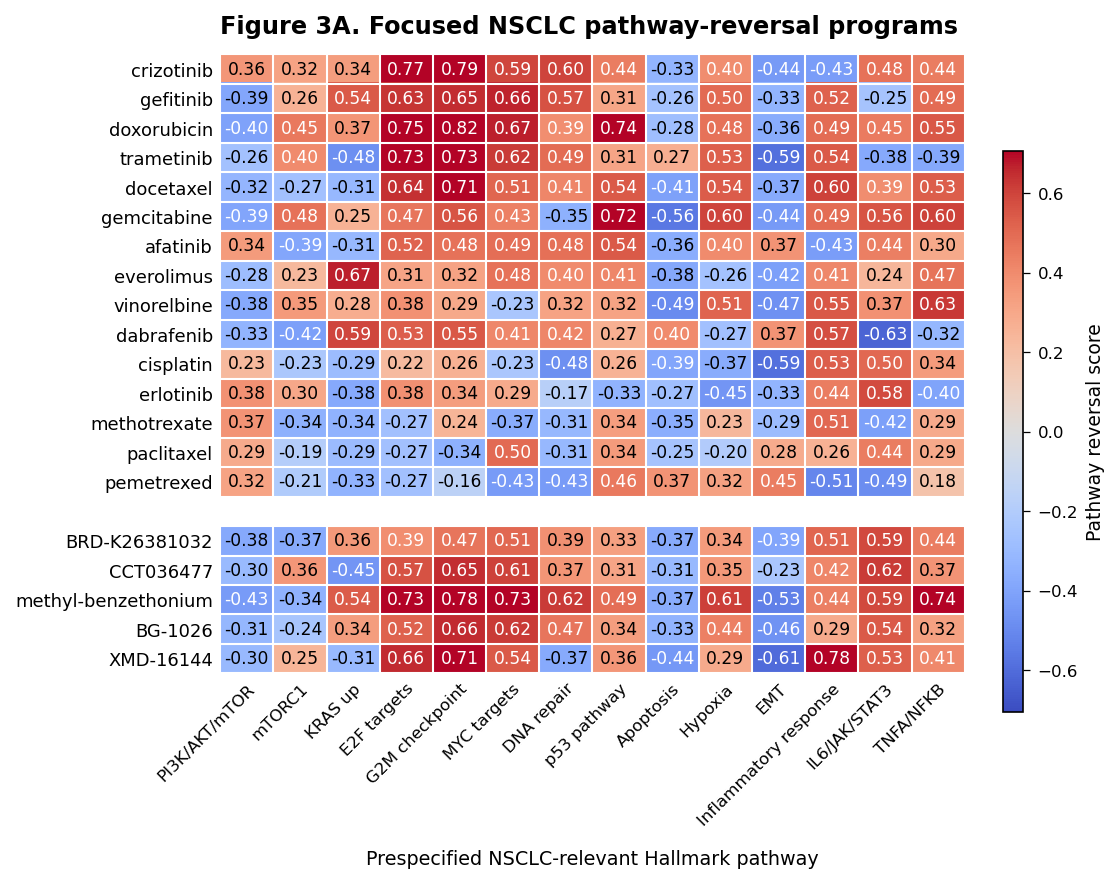

**Figure 3A heatmap matrix**

pathway_display,source,pert_iname,drug_group,rank,class_for_figure3,approval_type,PI3K/AKT/mTOR,mTORC1,KRAS up,E2F targets,G2M checkpoint,MYC targets,DNA repair,p53 pathway,Apoptosis,Hypoxia,EMT,Inflammatory response,IL6/JAK/STAT3,TNFA/NFKB
0,Observed LINCS,crizotinib,FDA-approved NSCLC reference,15,ALK/ROS1/MET TKI,single-agent approved,0.363318,0.315392,0.341173,0.769270,0.789811,0.591114,0.598655,0.443587,-0.326006,0.396427,-0.439444,-0.429855,0.478753,0.442323
1,Observed LINCS,gefitinib,FDA-approved NSCLC reference,30,EGFR TKI,single-agent approved,-0.386793,0.259144,0.540656,0.628759,0.650476,0.664087,0.567644,0.308197,-0.257458,0.496433,-0.329778,0.521379,-0.251553,0.492958
2,Observed LINCS,doxorubicin,FDA-approved NSCLC reference,35,anthracycline chemotherapy,listed for NSCLC,-0.403980,0.452221,0.368349,0.747944,0.824998,0.669209,0.391189,0.739385,-0.277383,0.475363,-0.364157,0.494503,0.450188,0.548360
3,Observed LINCS,trametinib,FDA-approved NSCLC reference,57,MEK inhibitor,combination component,-0.261270,0.402310,-0.477308,0.733185,0.727664,0.617854,0.492231,0.312480,0.271106,0.526658,-0.589126,0.543065,-0.377191,-0.385335
4,Observed LINCS,docetaxel,FDA-approved NSCLC reference,82,microtubule chemotherapy,single-agent approved / regimen component,-0.322971,-0.265517,-0.313139,0.640961,0.710895,0.509774,0.413966,0.544076,-0.408413,0.539128,-0.371581,0.602806,0.392992,0.533104
5,Observed LINCS,gemcitabine,FDA-approved NSCLC reference,171,nucleoside analog chemotherapy,regimen component,-0.393488,0.478207,0.254506,0.468600,0.559240,0.434412,-0.346864,0.717447,-0.559850,0.595590,-0.440555,0.490943,0.562431,0.602889
6,Observed LINCS,afatinib,FDA-approved NSCLC reference,310,EGFR/ERBB TKI,single-agent approved,0.344800,-0.388690,-0.312029,0.517246,0.478239,0.489528,0.482149,0.544675,-0.358906,0.398581,0.372247,-0.427301,0.436343,0.297175
7,Observed LINCS,everolimus,FDA-approved NSCLC reference,573,mTOR inhibitor,single-agent listed for NSCLC,-0.284416,0.226372,0.671333,0.308947,0.316288,0.478232,0.399072,0.414925,-0.384212,-0.257163,-0.418874,0.411180,0.241130,0.471236
8,Observed LINCS,vinorelbine,FDA-approved NSCLC reference,592,vinca alkaloid chemotherapy,regimen component,-0.376579,0.351755,0.280937,0.375849,0.294115,-0.234790,0.319081,0.316461,-0.492215,0.513520,-0.471506,0.547483,0.374982,0.626915
9,Observed LINCS,dabrafenib,FDA-approved NSCLC reference,808,BRAF inhibitor,combination component,-0.329267,-0.417621,0.592725,0.531397,0.550380,0.411267,0.416750,0.269067,0.398095,-0.268127,0.372867,0.568033,-0.625501,-0.315421


shape = (20, 20)


In [14]:
fig3a_matrix = plot_fig3a_heatmap(pathway_scores)
show_df(fig3a_matrix.reset_index(), "Figure 3A heatmap matrix", 30)

## 14. Figure 3B — candidate-centered similarity to individual FDA-approved NSCLC references

The primary Figure 3B uses the **quality-controlled full Hallmark collection**. To make the nearest approved reference immediately readable after the panel is reduced for the composite figure:

- each DEPICT candidate occupies one horizontal row;
- all FDA-approved NSCLC references remain visible as small gray points;
- the nearest, second-nearest, and third-nearest references are highlighted and labeled;
- the nearest reference receives the strongest visual emphasis;
- a summary table records the top-three references and the best-versus-second similarity margin.

The focused-pathway and 978-gene DGE versions use the same candidate-centered design as sensitivity analyses.


The compact Figure 3B style omits an internal title and places the legend higher above the axes to prevent overlap with top-reference labels.


**Figure 3B: full-Hallmark FDA-reference similarities**

,candidate,candidate_rank,reference,reference_rank,reference_reverse_score,reference_class,approval_type,match_priority,reference_broad_class,all_hallmark_spearman_rho,all_hallmark_spearman_p,n_pathways
22,BRD-K26381032,20,everolimus,573,0.420379,mTOR inhibitor,single-agent listed for NSCLC,small_molecule_targeted,PI3K/mTOR pathway,0.615584,0.000107,34
23,BRD-K26381032,20,gefitinib,30,0.666454,EGFR TKI,single-agent approved,small_molecule_targeted,Targeted TKI,0.486937,0.003495,34
29,BRD-K26381032,20,vinorelbine,592,0.417239,vinca alkaloid chemotherapy,regimen component,chemotherapy,Chemotherapy,0.398930,0.019434,34
17,BRD-K26381032,20,crizotinib,15,0.706004,ALK/ROS1/MET TKI,single-agent approved,small_molecule_targeted,Targeted TKI,0.383346,0.025225,34
19,BRD-K26381032,20,docetaxel,82,0.597358,microtubule chemotherapy,single-agent approved / regimen component,chemotherapy,Chemotherapy,0.308480,0.075894,34
20,BRD-K26381032,20,doxorubicin,35,0.655999,anthracycline chemotherapy,listed for NSCLC,chemotherapy,Chemotherapy,0.308174,0.076200,34
15,BRD-K26381032,20,afatinib,310,0.479281,EGFR/ERBB TKI,single-agent approved,small_molecule_targeted,Targeted TKI,0.266921,0.127003,34
24,BRD-K26381032,20,gemcitabine,171,0.533687,nucleoside analog chemotherapy,regimen component,chemotherapy,Chemotherapy,0.240336,0.170957,34
26,BRD-K26381032,20,paclitaxel,2783,0.308826,microtubule chemotherapy,regimen component,chemotherapy,Chemotherapy,0.145607,0.411268,34
16,BRD-K26381032,20,cisplatin,982,0.374543,platinum chemotherapy,regimen component,chemotherapy,Chemotherapy,0.134912,0.446819,34


shape = (75, 12)


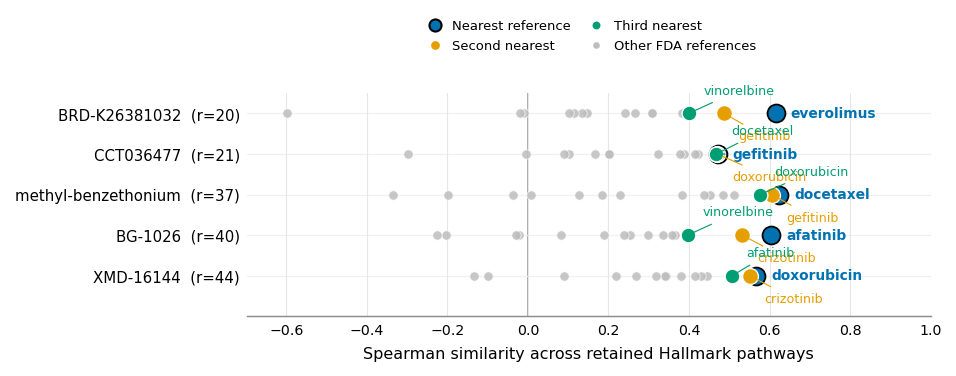

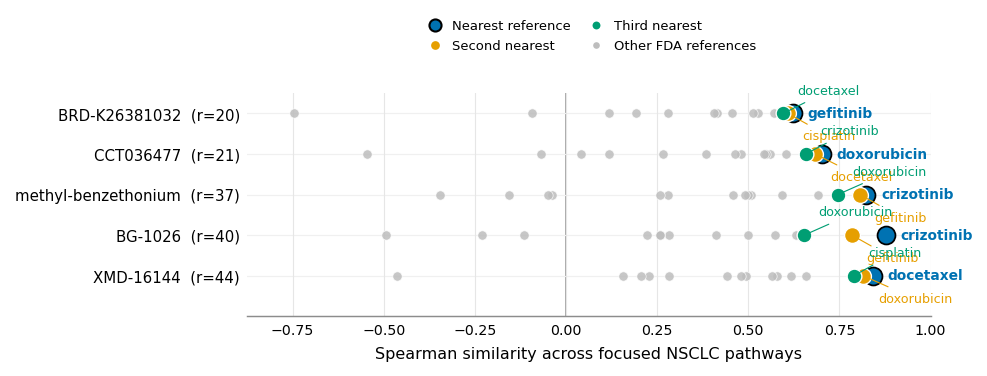

In [20]:
reference_meta = (
    fda_refs[["pert_iname", "canonical_name", "rank", "reverse_score", "class_for_figure3", "approval_type", "match_priority", "reference_broad_class"]]
    .drop_duplicates("pert_iname")
    .set_index("pert_iname")
)

# Primary: all quality-controlled Hallmark pathways.
fig3b_pathway_similarity_all, pathway_wide_all = pathway_similarity_records(
    pathway_scores_all,
    reference_meta,
    value_name="all_hallmark_spearman_rho",
)
fig3b_pathway_similarity_all = fig3b_pathway_similarity_all.sort_values(
    ["candidate_rank", "all_hallmark_spearman_rho"], ascending=[True, False]
)
fig3b_pathway_similarity_all.to_csv(TABLE_DIR / "fig3b_all_fda_reference_all_hallmark_spearman_similarity.csv", index=False)
show_df(fig3b_pathway_similarity_all, "Figure 3B: full-Hallmark FDA-reference similarities", 80)

fig3b_main_plot, fig3b_main_top_refs = plot_candidate_reference_similarity(
    fig3b_pathway_similarity_all,
    value_col="all_hallmark_spearman_rho",
    value_label="Spearman similarity across retained Hallmark pathways",
    stem="fig3b_all_hallmark_fda_reference_spearman_similarity_dotplot",
    title=None,
)

# Sensitivity analysis: prespecified NSCLC-focused pathways.
fig3b_focused_similarity, pathway_wide_focused = pathway_similarity_records(
    pathway_scores_focused,
    reference_meta,
    value_name="focused_pathway_spearman_rho",
)
fig3b_focused_similarity = fig3b_focused_similarity.sort_values(
    ["candidate_rank", "focused_pathway_spearman_rho"], ascending=[True, False]
)
fig3b_focused_similarity.to_csv(TABLE_DIR / "supp_fig3b_focused_pathway_fda_reference_spearman_similarity.csv", index=False)

fig3b_focused_plot, fig3b_focused_top_refs = plot_candidate_reference_similarity(
    fig3b_focused_similarity,
    value_col="focused_pathway_spearman_rho",
    value_label="Spearman similarity across focused NSCLC pathways",
    stem="supp_fig3b_focused_pathway_fda_reference_spearman_similarity_dotplot",
    title=None,
)

# Indices used by downstream gene-level and class-centroid analyses.
ref_index = [idx for idx in pathway_wide_all.index if idx[0] == "Observed LINCS"]
cand_index = [idx for idx in pathway_wide_all.index if idx[0] == "DEPICT-predicted LINCS"]


## 15. Figure 3B supplement — candidate-centered 978-gene DGE Pearson similarity

This companion analysis repeats the candidate-centered Figure 3B design using Pearson correlation on the 978-gene DGE vectors. All FDA references remain visible, while the top three references for each candidate are highlighted and labeled.


The compact Figure 3B style omits an internal title and places the legend higher above the axes to prevent overlap with top-reference labels.


**Supplementary Figure 3B: all FDA-reference 978-gene DGE Pearson similarities**

,candidate,candidate_rank,reference,reference_rank,reference_reverse_score,reference_class,approval_type,match_priority,reference_broad_class,dge978_pearson_r,dge978_pearson_p,n_genes
17,BRD-K26381032,20,crizotinib,15,0.706004,ALK/ROS1/MET TKI,single-agent approved,small_molecule_targeted,Targeted TKI,0.149818,2.528063e-06,978
28,BRD-K26381032,20,trametinib,57,0.628831,MEK inhibitor,combination component,small_molecule_targeted,MAPK pathway,0.128851,5.316327e-05,978
15,BRD-K26381032,20,afatinib,310,0.479281,EGFR/ERBB TKI,single-agent approved,small_molecule_targeted,Targeted TKI,0.125595,8.206172e-05,978
29,BRD-K26381032,20,vinorelbine,592,0.417239,vinca alkaloid chemotherapy,regimen component,chemotherapy,Chemotherapy,0.121920,1.322635e-04,978
18,BRD-K26381032,20,dabrafenib,808,0.390553,BRAF inhibitor,combination component,small_molecule_targeted,MAPK pathway,0.115522,2.943605e-04,978
22,BRD-K26381032,20,everolimus,573,0.420379,mTOR inhibitor,single-agent listed for NSCLC,small_molecule_targeted,PI3K/mTOR pathway,0.111526,4.754673e-04,978
19,BRD-K26381032,20,docetaxel,82,0.597358,microtubule chemotherapy,single-agent approved / regimen component,chemotherapy,Chemotherapy,0.104723,1.038697e-03,978
20,BRD-K26381032,20,doxorubicin,35,0.655999,anthracycline chemotherapy,listed for NSCLC,chemotherapy,Chemotherapy,0.095592,2.767136e-03,978
23,BRD-K26381032,20,gefitinib,30,0.666454,EGFR TKI,single-agent approved,small_molecule_targeted,Targeted TKI,0.088691,5.510740e-03,978
16,BRD-K26381032,20,cisplatin,982,0.374543,platinum chemotherapy,regimen component,chemotherapy,Chemotherapy,0.052039,1.038557e-01,978


shape = (75, 12)


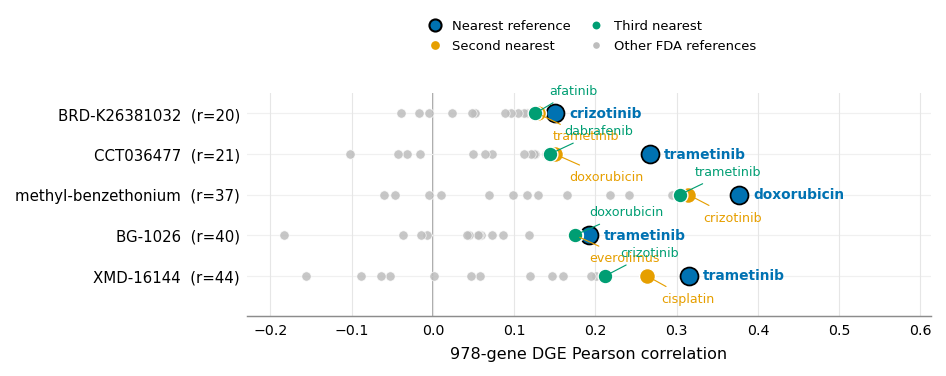

In [21]:
gene_cols = [c for c in common_gene_cols if c in profiles.columns]
gene_profiles = profiles.set_index(["source", "pert_iname", "rank"])[gene_cols]

gene_ref_records = []
for cidx in cand_index:
    cand_vec = gene_profiles.loc[cidx]
    for ridx in ref_index:
        ref_vec = gene_profiles.loc[ridx]
        r, pval, n = pearson_pair(cand_vec, ref_vec)
        ref_name = ridx[1]
        meta = reference_meta.loc[ref_name] if ref_name in reference_meta.index else pd.Series(dtype=object)
        gene_ref_records.append({
            "candidate": cidx[1],
            "candidate_rank": int(cidx[2]),
            "reference": ref_name,
            "reference_rank": int(ridx[2]),
            "reference_reverse_score": meta.get("reverse_score", np.nan),
            "reference_class": meta.get("class_for_figure3", np.nan),
            "approval_type": meta.get("approval_type", np.nan),
            "match_priority": meta.get("match_priority", np.nan),
            "reference_broad_class": meta.get("reference_broad_class", "Other"),
            "dge978_pearson_r": r,
            "dge978_pearson_p": pval,
            "n_genes": n,
        })

fig3b_gene_similarity_all = pd.DataFrame(gene_ref_records).sort_values(
    ["candidate_rank", "dge978_pearson_r"], ascending=[True, False]
)
fig3b_gene_similarity_all.to_csv(TABLE_DIR / "supp_fig3b_all_fda_reference_978gene_dge_pearson_similarity.csv", index=False)
show_df(fig3b_gene_similarity_all, "Supplementary Figure 3B: all FDA-reference 978-gene DGE Pearson similarities", 50)

fig3b_gene_plot, fig3b_gene_top_refs = plot_candidate_reference_similarity(
    fig3b_gene_similarity_all,
    value_col="dge978_pearson_r",
    value_label="978-gene DGE Pearson correlation",
    stem="supp_fig3b_all_fda_reference_978gene_dge_pearson_similarity_dotplot",
    title=None,
)


## 16. Figure 3C — full-Hallmark similarity to therapeutic-class centroids

Figure 3C summarizes similarity to multi-label therapeutic-class centroids using the quality-controlled full Hallmark representation. Main and sensitivity heatmaps now share the finalized Figure 4C palette, white gridlines, annotation treatment, frameless axes, and external colorbar. The 6.8 × 3.25 inch footprint matches the finalized lower left-column Figure 4 panel.


**Reference drugs used for multi-label class centroids**

,pert_iname,canonical_name,therapeutic_class,reference_rank,reference_reverse_score,class_for_figure3
0,gefitinib,gefitinib,EGFR TKI,30,0.666454,EGFR TKI
1,afatinib,afatinib,EGFR TKI,310,0.479281,EGFR/ERBB TKI
2,erlotinib,erlotinib,EGFR TKI,1943,0.330656,EGFR TKI
3,afatinib,afatinib,ERBB-family TKI,310,0.479281,EGFR/ERBB TKI
4,crizotinib,crizotinib,ALK/ROS1/MET TKI,15,0.706004,ALK/ROS1/MET TKI
5,trametinib,trametinib,MAPK/MEK/BRAF pathway,57,0.628831,MEK inhibitor
6,dabrafenib,dabrafenib,MAPK/MEK/BRAF pathway,808,0.390553,BRAF inhibitor
7,everolimus,everolimus,PI3K-AKT-mTOR pathway,573,0.420379,mTOR inhibitor
8,docetaxel,docetaxel,Microtubule chemotherapy,82,0.597358,microtubule chemotherapy
9,vinorelbine,vinorelbine,Microtubule chemotherapy,592,0.417239,vinca alkaloid chemotherapy


shape = (21, 6)


**Figure 3C: full-Hallmark class similarities**

,candidate,candidate_rank,therapeutic_class,all_hallmark_centroid_spearman_rho,all_hallmark_centroid_spearman_p,n_pathways,n_reference_drugs
16,BRD-K26381032,20,PI3K-AKT-mTOR pathway,0.615584,0.000107,34,1
17,BRD-K26381032,20,Microtubule chemotherapy,0.461879,0.005962,34,3
12,BRD-K26381032,20,EGFR TKI,0.431627,0.010807,34,3
14,BRD-K26381032,20,ALK/ROS1/MET TKI,0.383346,0.025225,34,1
22,BRD-K26381032,20,Anthracycline chemotherapy,0.308174,0.076200,34,1
21,BRD-K26381032,20,DNA-damage chemotherapy,0.302979,0.081547,34,2
13,BRD-K26381032,20,ERBB-family TKI,0.266921,0.127003,34,1
20,BRD-K26381032,20,Nucleoside analog chemotherapy,0.240336,0.170957,34,1
23,BRD-K26381032,20,Platinum chemotherapy,0.134912,0.446819,34,1
15,BRD-K26381032,20,MAPK/MEK/BRAF pathway,0.030099,0.865812,34,2


shape = (60, 7)


**Figure 3C: full-Hallmark assignment summary**

,candidate,candidate_rank,method,nearest_class,nearest_class_similarity,second_class,second_class_similarity,assignment_margin,reported_assignment
0,BG-1026,40,all Hallmark pathways,ERBB-family TKI,0.604584,ALK/ROS1/MET TKI,0.532162,0.072422,mixed/unresolved
1,BRD-K26381032,20,all Hallmark pathways,PI3K-AKT-mTOR pathway,0.615584,Microtubule chemotherapy,0.461879,0.153705,PI3K-AKT-mTOR pathway
2,CCT036477,21,all Hallmark pathways,EGFR TKI,0.484186,Microtubule chemotherapy,0.471963,0.012223,mixed/unresolved
3,XMD-16144,44,all Hallmark pathways,DNA-damage chemotherapy,0.641864,EGFR TKI,0.569442,0.072422,mixed/unresolved
4,methyl-benzethonium,37,all Hallmark pathways,Microtubule chemotherapy,0.592972,Anthracycline chemotherapy,0.576471,0.016501,mixed/unresolved


shape = (5, 9)


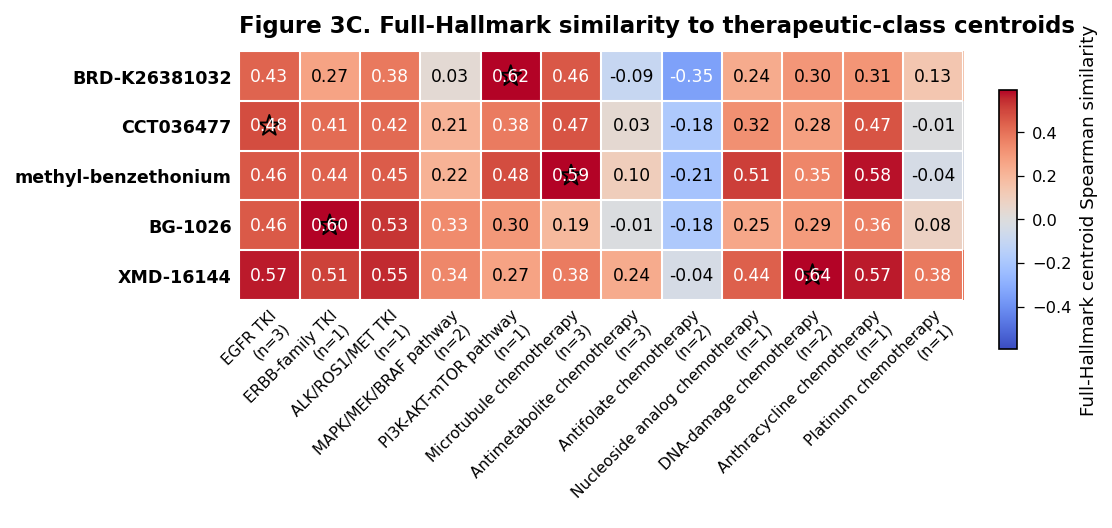

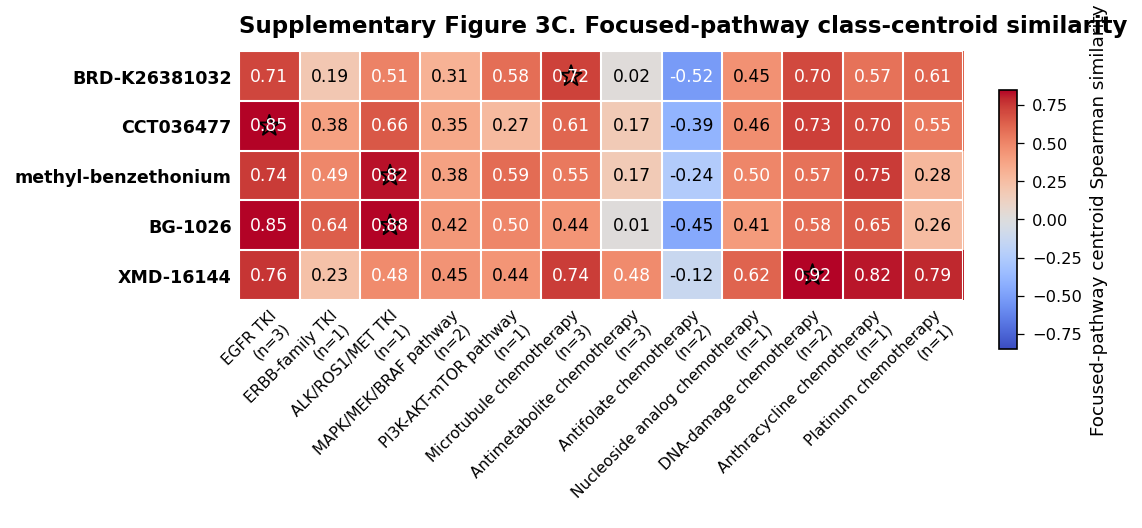

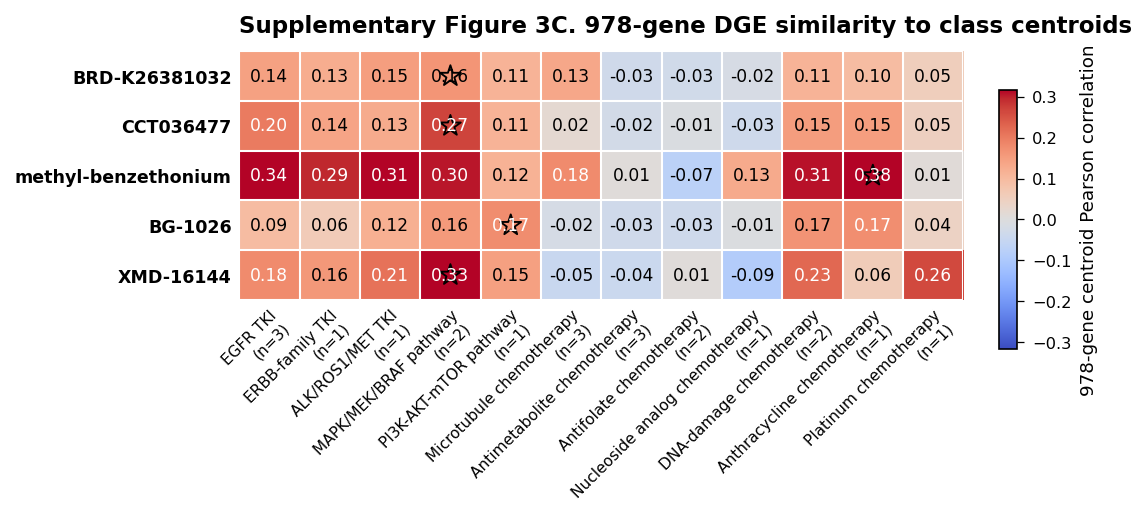

**Cross-method nearest-reference and nearest-class stability**

,candidate,candidate_rank,nearest_reference,nearest_reference_similarity,method,nearest_class,nearest_class_similarity,assignment_margin,reported_assignment
3,BRD-K26381032,20,crizotinib,0.149818,978-gene DGE,MAPK/MEK/BRAF pathway,0.164731,0.014913,mixed/unresolved
4,BRD-K26381032,20,everolimus,0.615584,all Hallmark pathways,PI3K-AKT-mTOR pathway,0.615584,0.153705,PI3K-AKT-mTOR pathway
5,BRD-K26381032,20,gefitinib,0.621978,focused NSCLC pathways,Microtubule chemotherapy,0.723077,0.013187,mixed/unresolved
6,CCT036477,21,trametinib,0.266842,978-gene DGE,MAPK/MEK/BRAF pathway,0.267198,0.066125,mixed/unresolved
7,CCT036477,21,gefitinib,0.471658,all Hallmark pathways,EGFR TKI,0.484186,0.012223,mixed/unresolved
8,CCT036477,21,doxorubicin,0.701099,focused NSCLC pathways,EGFR TKI,0.846154,0.118681,EGFR TKI
12,methyl-benzethonium,37,doxorubicin,0.376931,978-gene DGE,Anthracycline chemotherapy,0.376931,0.037640,mixed/unresolved
13,methyl-benzethonium,37,docetaxel,0.624446,all Hallmark pathways,Microtubule chemotherapy,0.592972,0.016501,mixed/unresolved
14,methyl-benzethonium,37,crizotinib,0.824176,focused NSCLC pathways,ALK/ROS1/MET TKI,0.824176,0.079121,mixed/unresolved
0,BG-1026,40,trametinib,0.192251,978-gene DGE,PI3K-AKT-mTOR pathway,0.174888,0.000277,mixed/unresolved


shape = (15, 9)


In [17]:
def build_pathway_class_similarity(pathway_scores_long, value_col_name):
    ref_long = pathway_scores_long[pathway_scores_long["source"] == "Observed LINCS"].copy()
    ref_long = ref_long.merge(
        reference_class_membership[["pert_iname", "therapeutic_class"]],
        on="pert_iname", how="inner",
    )
    centroid_long = (
        ref_long.dropna(subset=["pathway_reversal_score", "therapeutic_class"])
        .groupby(["therapeutic_class", "pathway_raw"], as_index=False, observed=False)
        .agg(
            mean_pathway_reversal=("pathway_reversal_score", "mean"),
            n_reference_drugs=("pert_iname", "nunique"),
        )
    )
    centroid_wide = centroid_long.pivot_table(
        index="therapeutic_class", columns="pathway_raw",
        values="mean_pathway_reversal", observed=False,
    )
    class_order = [c for c in THERAPEUTIC_CLASS_ORDER if c in set(centroid_long["therapeutic_class"].astype(str))]
    centroid_wide = centroid_wide.reindex(class_order)

    candidate_wide = pathway_scores_long[pathway_scores_long["source"] == "DEPICT-predicted LINCS"].pivot_table(
        index=["pert_iname", "rank"], columns="pathway_raw",
        values="pathway_reversal_score", aggfunc="mean",
    )
    common_paths = centroid_wide.columns.intersection(candidate_wide.columns)
    centroid_wide = centroid_wide[common_paths]
    candidate_wide = candidate_wide[common_paths]

    records = []
    for (cand, cand_rank), cand_vec in candidate_wide.iterrows():
        for cls in centroid_wide.index:
            rho, pval, n = spearman_pair(cand_vec, centroid_wide.loc[cls])
            n_ref = int(centroid_long.loc[centroid_long["therapeutic_class"].astype(str) == str(cls), "n_reference_drugs"].max())
            records.append({
                "candidate": cand,
                "candidate_rank": int(cand_rank),
                "therapeutic_class": str(cls),
                value_col_name: rho,
                value_col_name.replace("rho", "p"): pval,
                "n_pathways": n,
                "n_reference_drugs": n_ref,
            })
    return pd.DataFrame(records), centroid_long, centroid_wide


def summarize_assignment(sim_df, value_col, method_name):
    records = []
    for cand, sub in sim_df.groupby("candidate", sort=False):
        sub = sub.sort_values(value_col, ascending=False).reset_index(drop=True)
        best = sub.iloc[0]
        second = sub.iloc[1] if len(sub) > 1 else None
        margin = best[value_col] - second[value_col] if second is not None else np.nan
        unresolved = (
            pd.isna(best[value_col])
            or best[value_col] < UNRESOLVED_MIN_RHO
            or (pd.notna(margin) and margin < UNRESOLVED_MIN_MARGIN)
        )
        records.append({
            "candidate": cand,
            "candidate_rank": int(best["candidate_rank"]),
            "method": method_name,
            "nearest_class": best["therapeutic_class"],
            "nearest_class_similarity": best[value_col],
            "second_class": second["therapeutic_class"] if second is not None else np.nan,
            "second_class_similarity": second[value_col] if second is not None else np.nan,
            "assignment_margin": margin,
            "reported_assignment": "mixed/unresolved" if unresolved else best["therapeutic_class"],
        })
    return pd.DataFrame(records)

# ---------------------------------------------------------------------
# Primary Figure 3C: full Hallmark therapeutic-class centroids.
# ---------------------------------------------------------------------
fig3c_all_hallmark_class_similarity, all_centroid_long, all_centroid_wide = build_pathway_class_similarity(
    pathway_scores_all,
    "all_hallmark_centroid_spearman_rho",
)
fig3c_all_hallmark_class_similarity.to_csv(TABLE_DIR / "fig3c_all_hallmark_class_centroid_similarity.csv", index=False)
all_centroid_long.to_csv(TABLE_DIR / "fig3c_all_hallmark_class_centroids_long.csv", index=False)
all_centroid_wide.to_csv(TABLE_DIR / "fig3c_all_hallmark_class_centroids_wide.csv")

fig3c_all_assignment = summarize_assignment(
    fig3c_all_hallmark_class_similarity,
    "all_hallmark_centroid_spearman_rho",
    "all Hallmark pathways",
)
fig3c_all_assignment.to_csv(TABLE_DIR / "fig3c_all_hallmark_class_assignment_summary.csv", index=False)

show_df(reference_class_membership, "Reference drugs used for multi-label class centroids", 60)
show_df(fig3c_all_hallmark_class_similarity.sort_values(["candidate_rank", "all_hallmark_centroid_spearman_rho"], ascending=[True, False]), "Figure 3C: full-Hallmark class similarities", 80)
show_df(fig3c_all_assignment, "Figure 3C: full-Hallmark assignment summary", 20)

plot_candidate_class_heatmap(
    fig3c_all_hallmark_class_similarity,
    value_col="all_hallmark_centroid_spearman_rho",
    stem="fig3c_all_hallmark_class_centroid_spearman_heatmap",
    title="Figure 3C. Full-Hallmark similarity to therapeutic-class centroids",
    value_label="Full-Hallmark centroid Spearman similarity",
)

# ---------------------------------------------------------------------
# Sensitivity: focused NSCLC pathway centroids.
# ---------------------------------------------------------------------
fig3c_focused_class_similarity, focused_centroid_long, focused_centroid_wide = build_pathway_class_similarity(
    pathway_scores_focused,
    "focused_centroid_spearman_rho",
)
fig3c_focused_class_similarity.to_csv(TABLE_DIR / "supp_fig3c_focused_pathway_class_centroid_similarity.csv", index=False)
fig3c_focused_assignment = summarize_assignment(
    fig3c_focused_class_similarity,
    "focused_centroid_spearman_rho",
    "focused NSCLC pathways",
)

plot_candidate_class_heatmap(
    fig3c_focused_class_similarity,
    value_col="focused_centroid_spearman_rho",
    stem="supp_fig3c_focused_pathway_class_centroid_spearman_heatmap",
    title="Supplementary Figure 3C. Focused-pathway class-centroid similarity",
    value_label="Focused-pathway centroid Spearman similarity",
)

# ---------------------------------------------------------------------
# Sensitivity: 978-gene DGE Pearson correlation to class centroids.
# ---------------------------------------------------------------------
gene_cols = [c for c in common_gene_cols if c in profiles.columns]
gene_profile_reset = profiles[["source", "pert_iname", "rank"] + gene_cols].copy()
ref_gene = gene_profile_reset[gene_profile_reset["source"] == "Observed LINCS"].merge(
    reference_class_membership[["pert_iname", "therapeutic_class"]],
    on="pert_iname", how="inner",
)
gene_centroid_wide = (
    ref_gene.groupby("therapeutic_class", observed=False)[gene_cols]
    .mean()
    .reindex([c for c in THERAPEUTIC_CLASS_ORDER if c in set(reference_class_membership["therapeutic_class"].astype(str))])
)
gene_class_n = ref_gene.groupby("therapeutic_class", observed=False)["pert_iname"].nunique().reindex(gene_centroid_wide.index)
candidate_gene = gene_profile_reset[gene_profile_reset["source"] == "DEPICT-predicted LINCS"].set_index(["pert_iname", "rank"])[gene_cols]

gene_class_records = []
for (cand, cand_rank), cand_vec in candidate_gene.iterrows():
    for cls in gene_centroid_wide.index:
        r, pval, n = pearson_pair(cand_vec, gene_centroid_wide.loc[cls])
        gene_class_records.append({
            "candidate": cand, "candidate_rank": int(cand_rank),
            "therapeutic_class": str(cls),
            "dge978_centroid_pearson_r": r,
            "dge978_centroid_pearson_p": pval,
            "n_genes": n,
            "n_reference_drugs": int(gene_class_n.loc[cls]) if pd.notna(gene_class_n.loc[cls]) else 0,
        })
fig3c_gene_class_similarity = pd.DataFrame(gene_class_records)
fig3c_gene_class_similarity.to_csv(TABLE_DIR / "supp_fig3c_978gene_class_centroid_pearson_similarity.csv", index=False)
fig3c_gene_assignment = summarize_assignment(fig3c_gene_class_similarity, "dge978_centroid_pearson_r", "978-gene DGE")

plot_candidate_class_heatmap(
    fig3c_gene_class_similarity,
    value_col="dge978_centroid_pearson_r",
    stem="supp_fig3c_978gene_class_centroid_pearson_heatmap",
    title="Supplementary Figure 3C. 978-gene DGE similarity to class centroids",
    value_label="978-gene centroid Pearson correlation",
)

# ---------------------------------------------------------------------
# Cross-method nearest-reference and nearest-class stability summary.
# ---------------------------------------------------------------------
def nearest_reference_table(df, value_col, method):
    idx = df.groupby("candidate")[value_col].idxmax()
    out = df.loc[idx, ["candidate", "candidate_rank", "reference", value_col]].copy()
    out = out.rename(columns={"reference": "nearest_reference", value_col: "nearest_reference_similarity"})
    out["method"] = method
    return out

stability_reference = pd.concat([
    nearest_reference_table(fig3b_pathway_similarity_all, "all_hallmark_spearman_rho", "all Hallmark pathways"),
    nearest_reference_table(fig3b_focused_similarity, "focused_pathway_spearman_rho", "focused NSCLC pathways"),
    nearest_reference_table(fig3b_gene_similarity_all, "dge978_pearson_r", "978-gene DGE"),
], ignore_index=True)

stability_class = pd.concat([
    fig3c_all_assignment,
    fig3c_focused_assignment,
    fig3c_gene_assignment,
], ignore_index=True)

stability_summary = stability_reference.merge(
    stability_class[["candidate", "method", "nearest_class", "nearest_class_similarity", "assignment_margin", "reported_assignment"]],
    on=["candidate", "method"], how="outer",
).sort_values(["candidate_rank", "method"])
stability_summary.to_csv(TABLE_DIR / "supp_fig3_cross_method_nearest_reference_and_class_stability.csv", index=False)
show_df(stability_summary, "Cross-method nearest-reference and nearest-class stability", 30)


## 17. Final output checklist

The notebook now writes Figure 4-matched, composite-ready main panels and supporting diagnostics:

- **Figure 3A:** focused NSCLC pathway-reversal heatmap, tall left-panel format.
- **Figure 3B:** candidate-centered full-Hallmark similarity, with all references shown and the top three highlighted per candidate.
- **Figure 3C:** full-Hallmark candidate-to-class-centroid similarity, lower-right format.
- Full Hallmark overlap/variance/missingness QC tables and retained pathway list.
- Focused-pathway and 978-gene sensitivity plots.
- Cross-method nearest-reference and nearest-class stability table.

Plots display inline and are also saved as PDF, PNG, and SVG.


The compact Figure 3B style omits an internal title and places the legend higher above the axes to prevent overlap with top-reference labels.


In [18]:
print("Figures saved in:", FIG_DIR)
print("Tables saved in:", TABLE_DIR)

expected_outputs = [
    "fig3a_pathway_reversal_heatmap_matrix.csv",
    "fig3b_all_fda_reference_pathway_spearman_similarity.csv",
    "supp_fig3b_all_fda_reference_978gene_dge_pearson_similarity.csv",
    "fig3c_all_pathway_centroid_spearman_similarity.csv",
    "fig3c_pathway_therapeutic_class_assignment_summary.csv",
    "supp_fig3c_all_978gene_centroid_pearson_similarity.csv",
]

for filename in expected_outputs:
    path = TABLE_DIR / filename
    print(f"{filename}:", "OK" if path.exists() else "missing")

print("\nMain figure files to inspect:")
for stem in [
    "fig3a_pathway_reversal_heatmap_fda_refs_and_depict_only_candidates",
    "fig3b_all_fda_reference_pathway_spearman_similarity_dotplot",
    "fig3c_all_pathway_centroid_spearman_similarity_heatmap",
]:
    print(" -", FIG_DIR / f"{stem}.pdf")

print("\nSupplement/sensitivity figure files to inspect:")
for stem in [
    "supp_fig3b_all_fda_reference_978gene_dge_pearson_similarity_dotplot",
    "supp_fig3c_all_978gene_centroid_pearson_similarity_heatmap",
]:
    print(" -", FIG_DIR / f"{stem}.pdf")


Figures saved in: /work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/analysis/DrugScreening/Figure3_top50_five_candidate_hypothesis_generation/figures
Tables saved in: /work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/analysis/DrugScreening/Figure3_top50_five_candidate_hypothesis_generation/tables
fig3a_pathway_reversal_heatmap_matrix.csv: OK
fig3b_all_fda_reference_pathway_spearman_similarity.csv: OK
supp_fig3b_all_fda_reference_978gene_dge_pearson_similarity.csv: OK
fig3c_all_pathway_centroid_spearman_similarity.csv: OK
fig3c_pathway_therapeutic_class_assignment_summary.csv: OK
supp_fig3c_all_978gene_centroid_pearson_similarity.csv: OK

Main figure files to inspect:
 - /work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/analysis/DrugScreening/Figure3_top50_five_candidate_hypothesis_generation/figures/fig3a_pathway_reversal_heatmap_fd